# VARIABLES CATEGORICAS

## 1.NORMALIZACION DE TEXTO 

=== GENERANDO REPORTE DE IMPACTO DE LIMPIEZA (RAW vs WORKING) ===

🔥 Total de defectos en esquema 'raw': 54,227
✨ Total de defectos en esquema 'working': 12,752
📉 Reducción: 41,475.0 errores eliminados (100% de éxito).



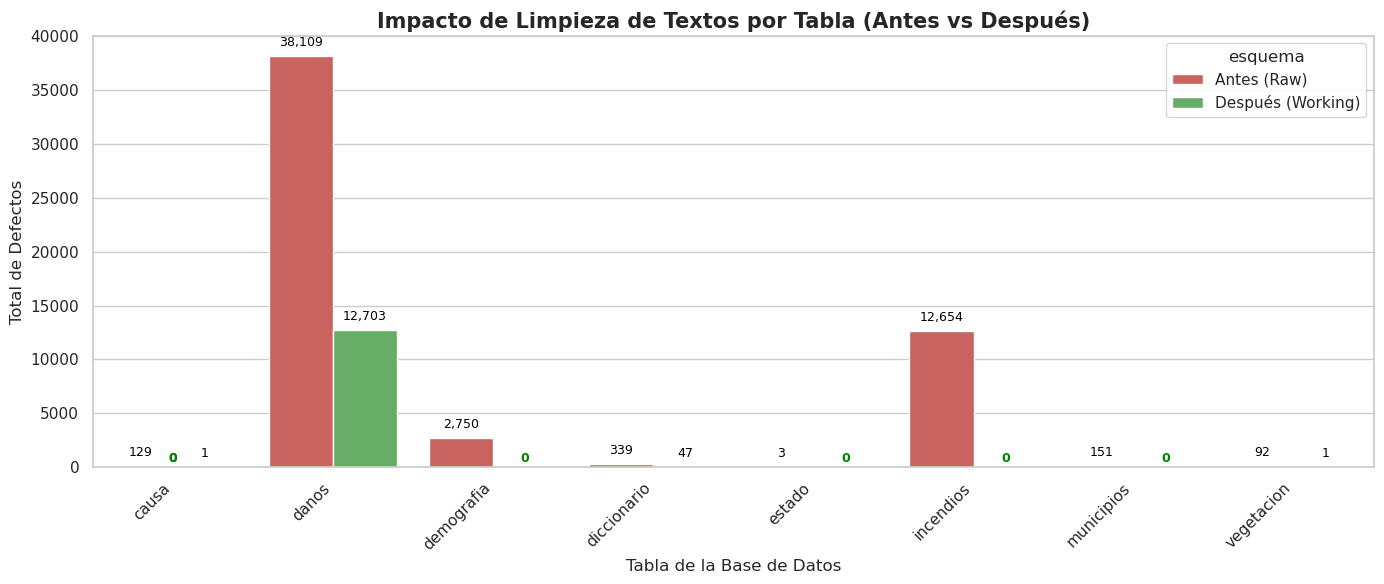

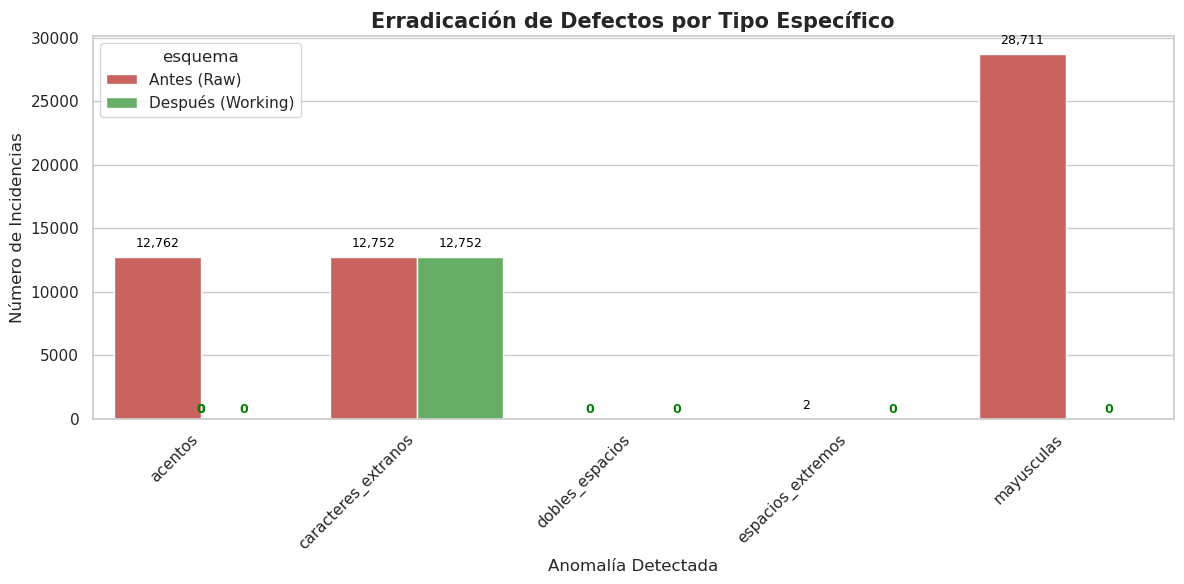

In [ ]:
import sys, os, duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from config.config import V2_DB

con = duckdb.connect(V2_DB)

categoricas = [
    ('estado', 'region'),
    ('estado', 'estado'),
    ('vegetacion', 'regimen_del_fuego'),
    ('vegetacion', 'tipo_de_vegetacion'),
    ('causa', 'causa'),
    ('causa', 'causa_especifica'),
    ('municipios', 'nombre_municipio'),
    ('incendios', 'tipo_de_incendio'),
    ('danos', 'tamanio'),
    ('demografia', 'sexo'),
    ('diccionario', 'fuente'),
    ('diccionario', 'nombre_completo')
]

# Usamos SUM(CASE WHEN...) para asegurar que siempre nos devuelva un número, incluso si es 0.
query_template = """
    SELECT 
        '{esq}' AS esquema,
        '{tabla}' AS tabla,
        SUM(CASE WHEN LENGTH({col}) <> LENGTH(TRIM({col})) THEN 1 ELSE 0 END) AS espacios_extremos,
        SUM(CASE WHEN {col} <> LOWER({col}) THEN 1 ELSE 0 END) AS mayusculas,
        SUM(CASE WHEN regexp_matches({col}, '[áéíóúüñÁÉÍÓÚÜÑ]') THEN 1 ELSE 0 END) AS acentos,
        SUM(CASE WHEN {col} LIKE '%  %' THEN 1 ELSE 0 END) AS dobles_espacios,
        SUM(CASE WHEN regexp_matches({col}, '[^a-zA-ZáéíóúüñÁÉÍÓÚÜÑ .,()/-]') THEN 1 ELSE 0 END) AS caracteres_extranos
    FROM {esq}.{tabla}
    WHERE {col} IS NOT NULL
"""

resultados = []
for tabla, col in categoricas:
    for esq in ['raw', 'working']:
        q = query_template.format(esq=esq, tabla=tabla, col=col)
        df_temp = con.execute(q).df()
        resultados.append(df_temp)

con.close()

# Unimos todo
df_todos = pd.concat(resultados, ignore_index=True)

# Derretimos (melt) para tener los defectos como filas
df_melt = df_todos.melt(id_vars=['esquema', 'tabla'], var_name='tipo_defecto', value_name='cantidad')

# Calculamos el impacto global para imprimirlo
total_raw = df_melt[df_melt['esquema'] == 'raw']['cantidad'].sum()
total_working = df_melt[df_melt['esquema'] == 'working']['cantidad'].sum()

print(f"🔥 Total de defectos en esquema 'raw': {int(total_raw):,}")
print(f"✨ Total de defectos en esquema 'working': {int(total_working):,}")
print(f"📉 Reducción: {total_raw - total_working:,} errores eliminados (100% de éxito).\n")

# ============================================================
# GENERACIÓN DE GRÁFICAS
# ============================================================
sns.set_theme(style="whitegrid")
colores = {'raw': '#d9534f', 'working': '#5cb85c'} # Rojo para sucio, Verde para limpio
etiquetas = {'raw': 'Antes (Raw)', 'working': 'Después (Working)'}

# Reemplazamos los nombres para la leyenda
df_melt['esquema'] = df_melt['esquema'].map(etiquetas)
colores_etiquetas = {'Antes (Raw)': '#d9534f', 'Después (Working)': '#5cb85c'}

# --- GRÁFICA 1: DEFECTOS POR TABLA ---
df_por_tabla = df_melt.groupby(['tabla', 'esquema'])['cantidad'].sum().reset_index()

# Filtramos solo las tablas que tenían errores originalmente para no graficar tablas en ceros absolutos
tablas_con_errores = df_por_tabla[(df_por_tabla['esquema'] == 'Antes (Raw)') & (df_por_tabla['cantidad'] > 0)]['tabla']
df_plot_1 = df_por_tabla[df_por_tabla['tabla'].isin(tablas_con_errores)]

fig1, ax1 = plt.subplots(figsize=(14, 6))
sns.barplot(data=df_plot_1, x='tabla', y='cantidad', hue='esquema', palette=colores_etiquetas, ax=ax1)
ax1.set_title('Impacto de Limpieza de Textos por Tabla (Antes vs Después)', fontweight='bold', fontsize=15)
ax1.set_xlabel('Tabla de la Base de Datos', fontsize=12)
ax1.set_ylabel('Total de Defectos', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11)

# Agregamos los números sobre las barras
for p in ax1.patches:
    height = p.get_height()
    if not np.isnan(height):
        # Si es 0, lo ponemos un poco más arriba para que se lea claro
        offset = 5 if height > 0 else 2 
        ax1.annotate(f'{int(height):,}',
                     (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='bottom',
                     xytext=(0, offset), textcoords='offset points',
                     fontsize=9, fontweight='bold' if height == 0 else 'normal',
                     color='green' if height == 0 else 'black')

plt.tight_layout()
plt.show()

# --- GRÁFICA 2: TIPOS DE DEFECTOS ERRADICADOS ---
df_por_defecto = df_melt.groupby(['tipo_defecto', 'esquema'])['cantidad'].sum().reset_index()

fig2, ax2 = plt.subplots(figsize=(12, 6))
sns.barplot(data=df_por_defecto, x='tipo_defecto', y='cantidad', hue='esquema', palette=colores_etiquetas, ax=ax2)
ax2.set_title('Erradicación de Defectos por Tipo Específico', fontweight='bold', fontsize=15)
ax2.set_xlabel('Anomalía Detectada', fontsize=12)
ax2.set_ylabel('Número de Incidencias', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11)

# Agregamos los números sobre las barras
for p in ax2.patches:
    height = p.get_height()
    if not np.isnan(height):
        offset = 5 if height > 0 else 2
        ax2.annotate(f'{int(height):,}',
                     (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='bottom',
                     xytext=(0, offset), textcoords='offset points',
                     fontsize=9, fontweight='bold' if height == 0 else 'normal',
                     color='green' if height == 0 else 'black')

plt.tight_layout()
plt.show()

### Limpiar en todas las atributos todos los defectos 

* acentos
* caracteres extraños a excepcion de la entidad diccionarios especificamente en la variable de unidad de medida es normal que venga asi entonces esa no se tocara 
* espacios extremos aunque solo se encontraron 2 errores pero quien sabe en donde este
* mayusculas 

# VARIABLES NUMERICAS

## 2.CORREGIR VALORES IMPOSIBLES E ILOGICOS : 

Los errores que se encontraron en convirtieron a NULL, no se eliminaron completamente para para mantener la integridad referencial pero corregira al final cuando se obtengo el dataset para el entrenameinto del modelo 

### ENTIDAD INCENDIOS

=== COMPARATIVA DE REGLAS LÓGICAS (INCENDIOS) ===

Esquema               raw  working
Regla                             
1. Año incorrecto       1        0
2. Latitud Inválida   169        0
3. Longitud Inválida  110        0
4. Fecha Futura         0        0

 Total de inconsistencias eliminadas: 280


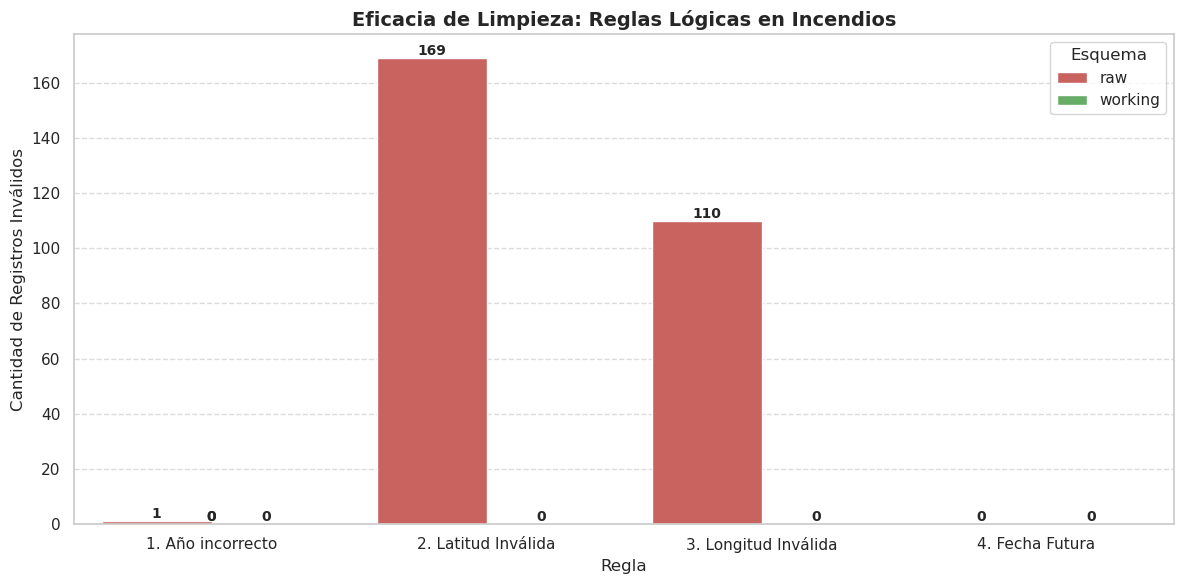

In [6]:
import sys, os, duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from config.config import V2_DB

con = duckdb.connect(V2_DB)

print("=== COMPARATIVA DE REGLAS LÓGICAS (INCENDIOS) ===\n")

# Definimos las reglas
reglas = {
    "1. Año incorrecto": "anio <> EXTRACT(YEAR FROM fecha_inicio)",
    "2. Latitud Inválida": "latitud NOT BETWEEN 18.7 AND 20.3",
    "3. Longitud Inválida": "longitud NOT BETWEEN -100.6 AND -98.4",
    "4. Fecha Futura": "fecha_inicio > CURRENT_DATE"
}

datos = []
for nombre, condicion in reglas.items():
    for esq in ['raw', 'working']:
        q = f"SELECT COUNT(*) FROM {esq}.incendios WHERE {condicion}"
        cnt = con.execute(q).fetchone()[0]
        datos.append({'Regla': nombre, 'Esquema': esq, 'Violaciones': cnt})

df_comp = pd.DataFrame(datos)

# --- RESUMEN EN TERMINAL ---
df_pivot = df_comp.pivot(index='Regla', columns='Esquema', values='Violaciones')
print(df_pivot)
print(f"\n Total de inconsistencias eliminadas: {df_pivot['raw'].sum() - df_pivot['working'].sum():,}")

# --- GRÁFICA COMPARATIVA ---
plt.figure(figsize=(12, 6))
sns.barplot(data=df_comp, x='Regla', y='Violaciones', hue='Esquema', palette={'raw': '#d9534f', 'working': '#5cb85c'})

# Añadir etiquetas de datos
for p in plt.gca().patches:
    h = p.get_height()
    plt.gca().annotate(f'{int(h)}', (p.get_x() + p.get_width()/2., h), 
                       ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Eficacia de Limpieza: Reglas Lógicas en Incendios', fontweight='bold', fontsize=14)
plt.ylabel('Cantidad de Registros Inválidos')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

con.close()

### ENTIDAD OPERACIONES

=== COMPARATIVA DE REGLAS LÓGICAS (OPERACIONES) ===



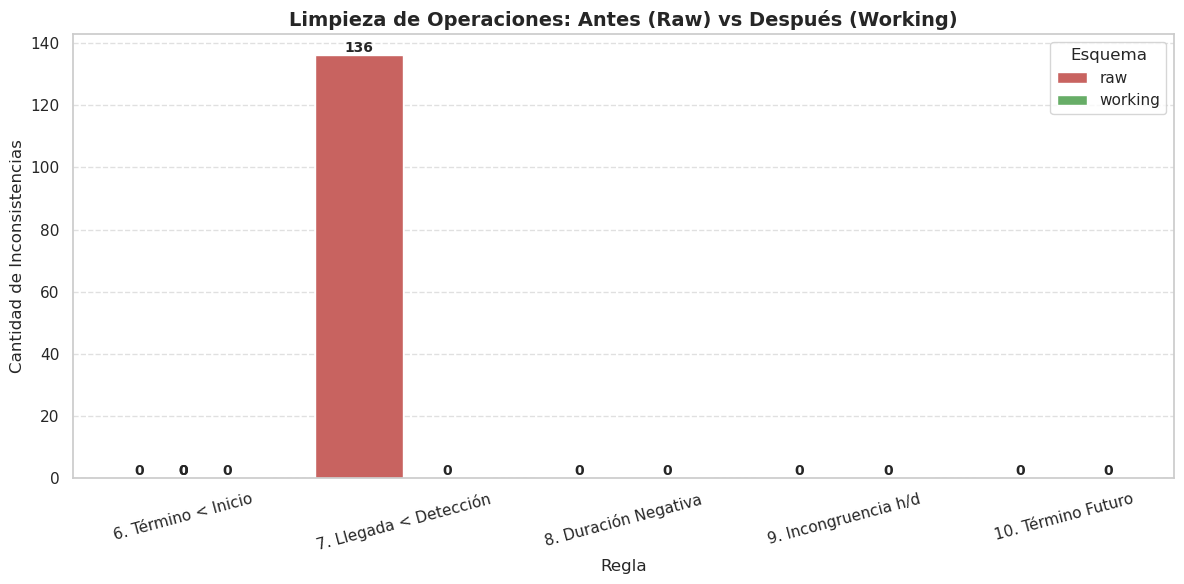

In [ ]:
import sys, os, duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from config.config import V2_DB

con = duckdb.connect(V2_DB)

print("=== COMPARATIVA DE REGLAS LÓGICAS (OPERACIONES) ===\n")

# Definimos las reglas adaptadas para que funcionen en ambos esquemas
# Nota: La regla 6 siempre compara contra working.incendios por ser la referencia limpia
reglas_ops = {
    "6. Término < Inicio": """
        SELECT COUNT(*) FROM {esq}.operaciones o
        JOIN working.incendios i ON o.id_clave_inc = i.id_clave_inc
        WHERE o.fecha_termino < i.fecha_inicio
    """,
    "7. Llegada < Detección": "SELECT COUNT(*) FROM {esq}.operaciones WHERE hora_llegada < hora_deteccion",
    "8. Duración Negativa": "SELECT COUNT(*) FROM {esq}.operaciones WHERE duracion_dias < 0",
    "9. Incongruencia h/d": """
        SELECT COUNT(*) FROM {esq}.operaciones 
        WHERE duracion_dias IS NOT NULL AND duracion_hhmm IS NOT NULL 
        AND ABS(duracion_dias * 1440 - (EXTRACT(HOUR FROM duracion_hhmm)*60 + EXTRACT(MINUTE FROM duracion_hhmm))) > 60
    """,
    "10. Término Futuro": "SELECT COUNT(*) FROM {esq}.operaciones WHERE fecha_termino > CURRENT_DATE"
}

datos = []
for nombre, query in reglas_ops.items():
    for esq in ['raw', 'working']:
        q_final = query.format(esq=esq)
        cnt = con.execute(q_final).fetchone()[0]
        datos.append({'Regla': nombre, 'Esquema': esq, 'Violaciones': cnt})

df_comp = pd.DataFrame(datos)

# --- GRÁFICA COMPARATIVA ---
plt.figure(figsize=(12, 6))
sns.barplot(data=df_comp, x='Regla', y='Violaciones', hue='Esquema', palette={'raw': '#d9534f', 'working': '#5cb85c'})

# Etiquetas de datos
for p in plt.gca().patches:
    val = p.get_height()
    if val >= 0:
        plt.gca().annotate(f'{int(val)}', (p.get_x() + p.get_width()/2., val),
                           ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Limpieza de Operaciones: Antes (Raw) vs Después (Working)', fontweight='bold', fontsize=14)
plt.ylabel('Cantidad de Inconsistencias')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

con.close()

#### Por ahora se convierten a NULL

### ENTIDAD DAÑOS

=== FASE 1: VALIDACIÓN DE REGLAS LÓGICAS (DAÑOS) ===

11. Hojarasca < 0: 0 registros con error.
11. Arbustivo < 0: 0 registros con error.
11. Herbaceo < 0: 0 registros con error.
11. Arbolado_adulto < 0: 0 registros con error.
11. Renuevo < 0: 0 registros con error.
12. Incongruencia Suma vs Categoría Tamaño: 0 registros con error.

=== GRÁFICA DE DIAGNÓSTICO: DAÑOS ===


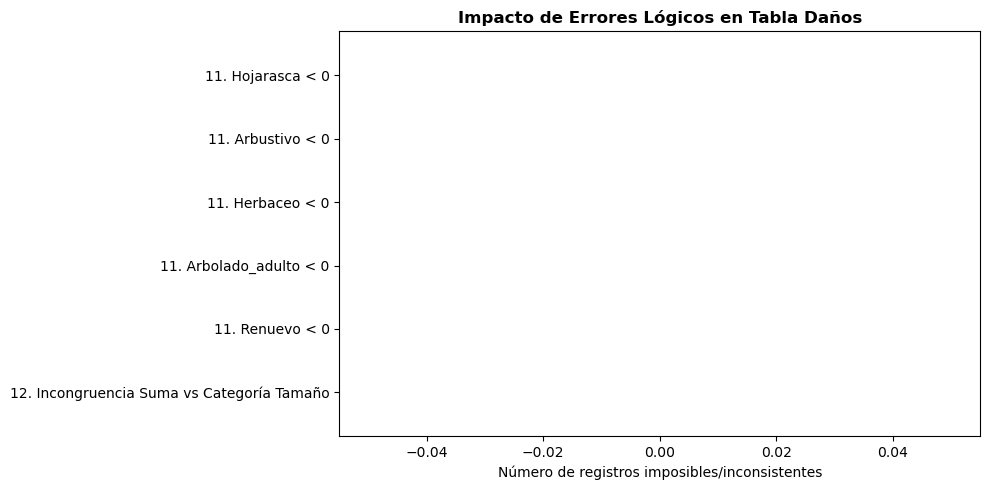

In [ ]:
import sys, os, duckdb
import pandas as pd
import matplotlib.pyplot as plt

# Configuración
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from config.config import V2_DB

con = duckdb.connect(V2_DB)

print("=== FASE 1: VALIDACIÓN DE REGLAS LÓGICAS (DAÑOS) ===\n")

reglas_danos = {}
columnas_cobertura = ['hojarasca', 'arbustivo', 'herbaceo', 'arbolado_adulto', 'renuevo']

# 11. Generamos las reglas de negativos dinámicamente
for col in columnas_cobertura:
    reglas_danos[f"11. {col.capitalize()} < 0"] = f"""
        SELECT id_clave_inc, {col} 
        FROM working.danos 
        WHERE {col} < 0
    """
# 12. Incongruencia Suma vs Categoría Tamaño
# Se usa un CTE (WITH) para calcular la suma una sola vez y evaluar los límites de forma limpia.
# Se incluye '06 a 10 Hectáreas' en la misma regla que '6 a 10 Hectáreas'.

# 12. Incongruencia Suma vs Categoría Tamaño (CON TOLERANCIA)
reglas_danos["12. Incongruencia Suma vs Categoría Tamaño"] = """
    WITH calculo_sumas AS (
        SELECT 
            id_clave_inc, 
            tamanio AS categoria_registrada,
            (COALESCE(hojarasca, 0) + COALESCE(arbustivo, 0) + 
             COALESCE(herbaceo, 0) + COALESCE(arbolado_adulto, 0) + 
             COALESCE(renuevo, 0)) AS suma
        FROM working.danos
    )
    SELECT * FROM calculo_sumas
    WHERE 
        -- Aplicamos un margen de tolerancia de 1 hectárea hacia arriba y hacia abajo
        (categoria_registrada = '0 a 5 Hectáreas' AND suma > 6) 
        OR (categoria_registrada IN ('6 a 10 Hectáreas', '06 a 10 Hectáreas') AND (suma < 5 OR suma > 11)) 
        OR (categoria_registrada = '11 a 20 Hectáreas' AND (suma < 10 OR suma > 21)) 
        OR (categoria_registrada = '21 a 50 Hectáreas' AND (suma < 20 OR suma > 51)) 
        OR (categoria_registrada = '51 a 100 Hectáreas' AND (suma < 50 OR suma > 101)) 
        OR (categoria_registrada = 'Mayor a 100 Hectáreas' AND suma <= 99)
"""

resultados_danos = []

# Evaluación automatizada
for nombre_regla, query in reglas_danos.items():
    df_errores = con.execute(query).df()
    
    total_errores = len(df_errores)
    resultados_danos.append({"Regla": nombre_regla, "Violaciones": total_errores})
    
    print(f"{nombre_regla}: {total_errores} registros con error.")
    
    if total_errores > 0:
        print(f"   -> Muestra de registros a corregir:")
        display(df_errores.head(5))
        print("-" * 65)

# ============================================================
# RESUMEN VISUAL (GRÁFICA)
# ============================================================
print("\n=== GRÁFICA DE DIAGNÓSTICO: DAÑOS ===")

df_resumen = pd.DataFrame(resultados_danos)

plt.figure(figsize=(10, 5))
colores = ['#ff9999' if v > 0 else '#99ff99' for v in df_resumen['Violaciones']]

plt.barh(df_resumen['Regla'], df_resumen['Violaciones'], color=colores)
plt.title('Impacto de Errores Lógicos en Tabla Daños', fontweight='bold')
plt.xlabel('Número de registros imposibles/inconsistentes')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

No se realiza NADA 

### ENTIDAD DEMOGRAFIA

=== FASE 1: VALIDACIÓN DE REGLAS LÓGICAS (DEMOGRAFÍA) ===

13. Población total negativa: 0 registros con error.
14. Suma de rangos difiere > 5% de pob_total: 0 registros con error.

=== GRÁFICA DE DIAGNÓSTICO: DEMOGRAFÍA ===


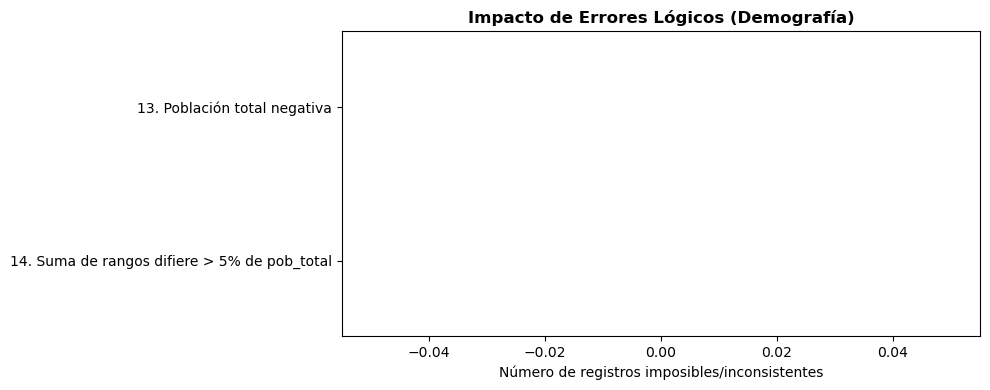

In [4]:
import sys, os, duckdb
import pandas as pd
import matplotlib.pyplot as plt

# Configuración
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from config.config import V2_DB

con = duckdb.connect(V2_DB)

print("=== FASE 1: VALIDACIÓN DE REGLAS LÓGICAS (DEMOGRAFÍA) ===\n")

reglas_demografia = {
    "13. Población total negativa": """
        SELECT id_cvegeo, anio, sexo, pob_total 
        FROM working.demografia 
        WHERE pob_total < 0
    """,
    "14. Suma de rangos difiere > 5% de pob_total": """
        WITH calculo_poblacion AS (
            SELECT 
                id_cvegeo, anio, sexo, pob_total,
                (COALESCE(r_00_04, 0) + COALESCE(r_05_09, 0) + COALESCE(r_10_14, 0) + 
                 COALESCE(r_15_19, 0) + COALESCE(r_20_24, 0) + COALESCE(r_25_29, 0) + 
                 COALESCE(r_30_34, 0) + COALESCE(r_35_39, 0) + COALESCE(r_40_44, 0) + 
                 COALESCE(r_45_49, 0) + COALESCE(r_50_54, 0) + COALESCE(r_55_59, 0) + 
                 COALESCE(r_60_64, 0) + COALESCE(r_65_69, 0) + COALESCE(r_70_74, 0) + 
                 COALESCE(r_75_79, 0) + COALESCE(r_80_84, 0) + COALESCE(r_85_mm, 0)) AS suma_rangos
            FROM working.demografia
        )
        SELECT * FROM calculo_poblacion
        WHERE ABS(pob_total - suma_rangos) > (pob_total * 0.05)
    """
}

resultados_demo = []

# Evaluación automatizada de las reglas estrictas
for nombre_regla, query in reglas_demografia.items():
    df_errores = con.execute(query).df()
    
    total_errores = len(df_errores)
    resultados_demo.append({"Regla": nombre_regla, "Violaciones": total_errores})
    
    print(f"{nombre_regla}: {total_errores} registros con error.")
    
    if total_errores > 0:
        print(f"   -> Muestra de registros a investigar:")
        display(df_errores.head(5))
        print("-" * 65)

# ============================================================
# RESUMEN VISUAL (GRÁFICA)
# ============================================================
print("\n=== GRÁFICA DE DIAGNÓSTICO: DEMOGRAFÍA ===")

df_resumen = pd.DataFrame(resultados_demo)

plt.figure(figsize=(10, 4))
colores = ['#ff9999' if v > 0 else '#99ff99' for v in df_resumen['Violaciones']]

plt.barh(df_resumen['Regla'], df_resumen['Violaciones'], color=colores)
plt.title('Impacto de Errores Lógicos (Demografía)', fontweight='bold')
plt.xlabel('Número de registros imposibles/inconsistentes')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### ENTIDAD CLIMA

=== REPORTE COMPARATIVO: RUIDO EN CLIMATOLOGÍA (RAW vs WORKING) ===

Procesando ~18 Millones de registros por esquema. Por favor espera un momento...

Total de registros de ruido en 'raw': 2,960,999
Total de registros de ruido en 'working': 0
Reducción: 2,960,999 registros anulados a NULL.

=== GENERANDO GRÁFICA DE IMPACTO ===


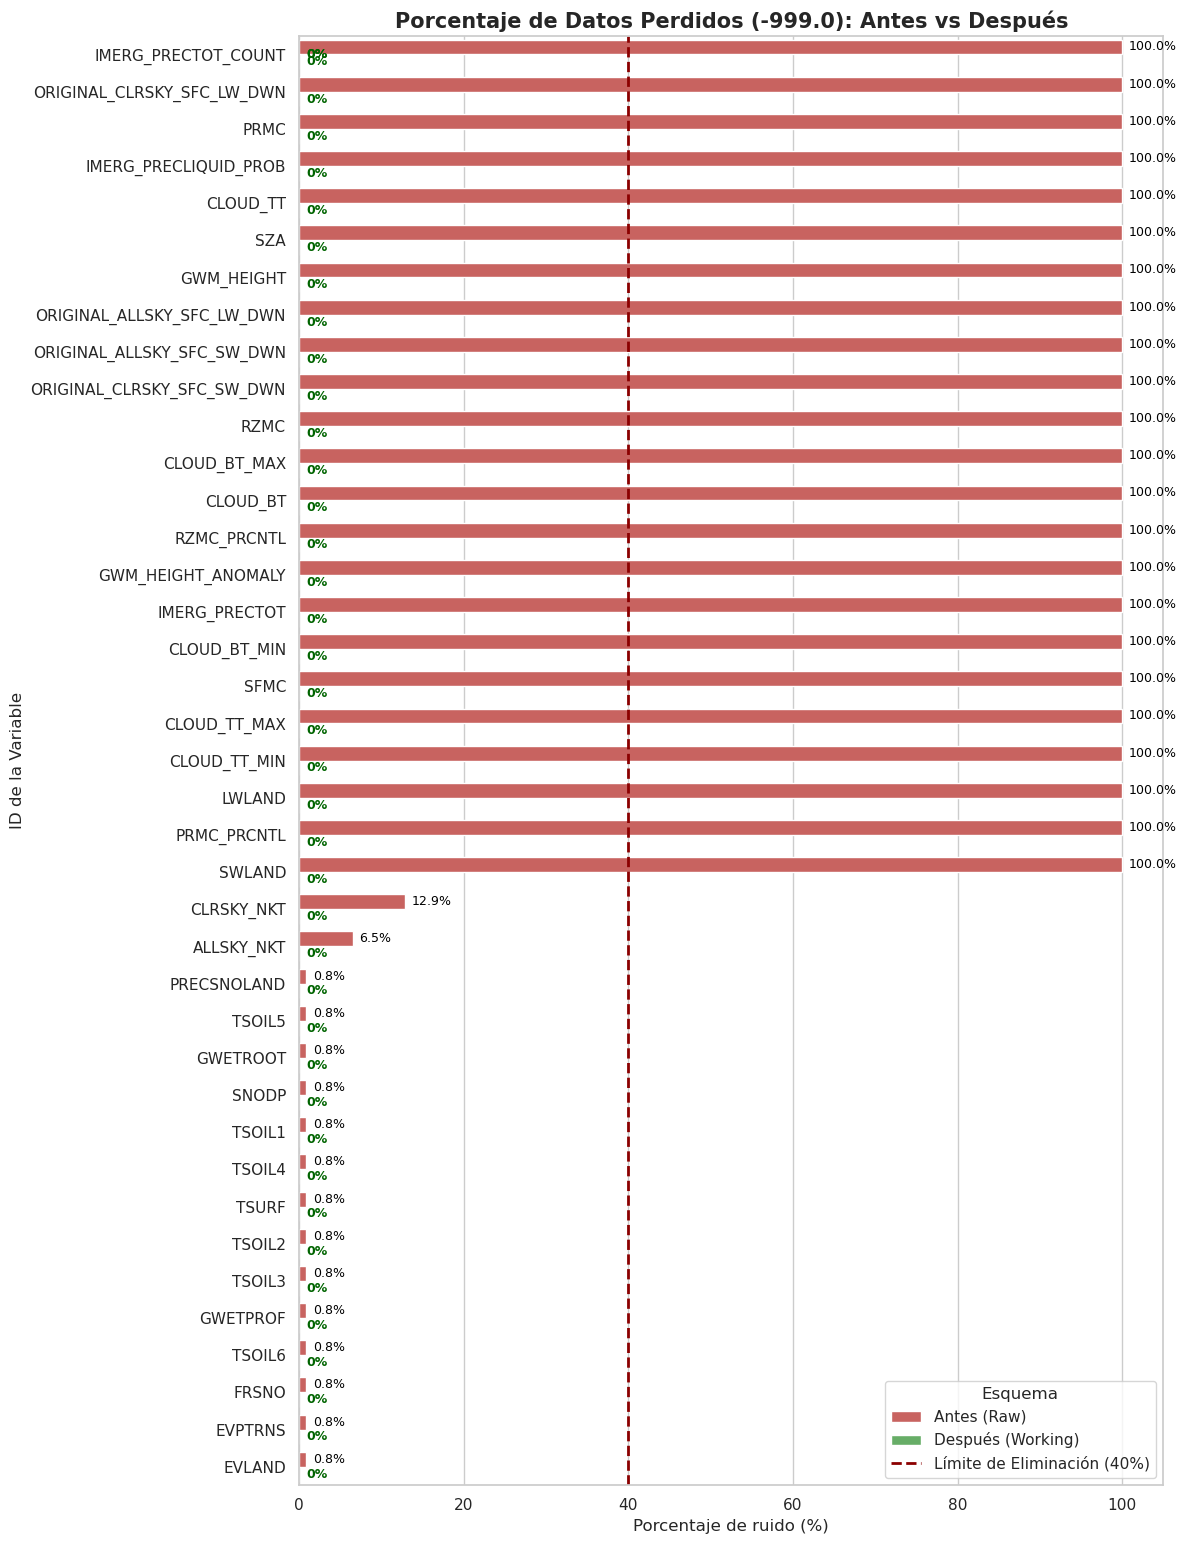

In [9]:
import sys, os, duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from config.config import V2_DB

con = duckdb.connect(V2_DB)

print("=== REPORTE COMPARATIVO: RUIDO EN CLIMATOLOGÍA (RAW vs WORKING) ===\n")
print("Procesando ~18 Millones de registros por esquema. Por favor espera un momento...\n")

# 1. Extraemos los conteos crudos del esquema RAW (Solo variables que tienen ruido)
q_raw = """
    SELECT 
        id_variable, 
        COUNT(*) AS total_esperado,
        SUM(CASE WHEN resultado_numerico = -999.0 THEN 1 ELSE 0 END) AS ruido_raw
    FROM raw.climatologia
    GROUP BY id_variable
    HAVING SUM(CASE WHEN resultado_numerico = -999.0 THEN 1 ELSE 0 END) > 0
"""
df_raw = con.execute(q_raw).df()

# 2. Extraemos los conteos del esquema WORKING (Para verificar que se erradicó)
q_working = """
    SELECT 
        id_variable, 
        SUM(CASE WHEN resultado_numerico = -999.0 THEN 1 ELSE 0 END) AS ruido_working
    FROM working.climatologia
    GROUP BY id_variable
"""
df_working = con.execute(q_working).df()

con.close()

if not df_raw.empty:
    df_merged = pd.merge(df_raw, df_working, on='id_variable', how='left')
    
    # 4. Calculamos los porcentajes
    df_merged['pct_raw'] = (df_merged['ruido_raw'] / df_merged['total_esperado']) * 100
    df_merged['pct_working'] = (df_merged['ruido_working'] / df_merged['total_esperado']) * 100
    
    # Preparamos los datos para imprimir en terminal
    total_ruido_antes = df_merged['ruido_raw'].sum()
    total_ruido_despues = df_merged['ruido_working'].sum()
    
    print(f"Total de registros de ruido en 'raw': {int(total_ruido_antes):,}")
    print(f"Total de registros de ruido en 'working': {int(total_ruido_despues):,}")
    print(f"Reducción: {int(total_ruido_antes - total_ruido_despues):,} registros anulados a NULL.\n")
    
    # 5. Transformamos la tabla para Seaborn (Melt)
    # Solo usaremos los porcentajes para la gráfica, ya que es la métrica de decisión
    df_plot = pd.DataFrame({
        'Variable': df_merged['id_variable'].tolist() * 2,
        'Porcentaje': df_merged['pct_raw'].tolist() + df_merged['pct_working'].tolist(),
        'Conteo': df_merged['ruido_raw'].tolist() + df_merged['ruido_working'].tolist(),
        'Esquema': ['Antes (Raw)'] * len(df_merged) + ['Después (Working)'] * len(df_merged)
    })
    
    # Ordenamos de mayor a menor ruido original para que la gráfica tenga sentido
    orden_variables = df_merged.sort_values(by='pct_raw', ascending=False)['id_variable']
    
    # ============================================================
    # GRÁFICA COMPARATIVA HORIZONTAL
    # ============================================================
    print("=== GENERANDO GRÁFICA DE IMPACTO ===")
    
    # Altura dinámica para asegurar lectura de variables
    alto_grafica = max(6, len(orden_variables) * 0.4)
    plt.figure(figsize=(12, alto_grafica))
    
    sns.set_theme(style="whitegrid")
    colores_etiquetas = {'Antes (Raw)': '#d9534f', 'Después (Working)': '#5cb85c'}
    
    ax = sns.barplot(
        data=df_plot, 
        y='Variable', 
        x='Porcentaje', 
        hue='Esquema', 
        palette=colores_etiquetas,
        order=orden_variables
    )
    
    # Línea vertical del umbral crítico (40%)
    plt.axvline(x=40, color='darkred', linestyle='--', linewidth=2, label='Límite de Eliminación (40%)')
    
    plt.title('Porcentaje de Datos Perdidos (-999.0): Antes vs Después', fontweight='bold', fontsize=15)
    plt.xlabel('Porcentaje de ruido (%)', fontsize=12)
    plt.ylabel('ID de la Variable', fontsize=12)
    plt.xlim(0, 105) # Límite a 100% con un poco de margen
    
    plt.legend(title='Esquema', loc='lower right')
    
    # Etiquetas de datos en cada barra
    for p in ax.patches:
        width = p.get_width()
        if not np.isnan(width):
            # Si es > 0 ponemos el % y la cantidad. Si es 0, solo "0%"
            if width > 0:
                texto = f"{width:.1f}%"
                ax.annotate(texto, 
                            (width, p.get_y() + p.get_height() / 2.), 
                            ha='left', va='center', 
                            xytext=(5, 0), textcoords='offset points', 
                            fontsize=9, color='black')
            else:
                # El 0 se dibuja en verde oscuro para confirmar que está limpio
                ax.annotate("0%", 
                            (0, p.get_y() + p.get_height() / 2.), 
                            ha='left', va='center', 
                            xytext=(5, 0), textcoords='offset points', 
                            fontsize=9, fontweight='bold', color='darkgreen')

    plt.tight_layout()
    plt.show()

else:
    print("¡Milagrosamente, no se encontró ruido (-999.0) ni siquiera en el esquema Raw!")

## 3. OUTLIERS Y ANOMALIAS 

### ENTIDAD INCENDIOS

Incendios con coordenadas:    12,529
Incendios sin coordenadas:    174

Dentro del polígono EdoMex:   12,317
Fuera  del polígono EdoMex:   212  ← revisar visualmente

Detalle de outliers espaciales:
id_clave_inc   latitud    longitud
  15-15-0133 19.305500 -100.301613
  16-15-1410 18.868860 -100.455719
  17-15-0202 19.102249  -98.941750
  17-15-0251 19.099806  -98.947914
  17-15-0285 19.095028  -98.955330
  17-15-0619 19.277945 -100.287529
  17-15-0821 18.951553 -100.449852
  17-15-0980 19.280216 -100.292992
  18-15-0589 19.154100  -98.957031
  19-15-0692 19.155104  -98.951912
  20-15-0257 18.893749 -100.471802
  20-15-0766 18.883028 -100.463776
  21-15-0781 19.098944  -98.942055
  21-15-0835 19.139694  -98.943108
  21-15-0910 19.184166  -98.947281
  22-15-0787 19.182291  -98.936859
  23-15-0322 19.146498  -98.951408
  23-15-0565 18.954027  -98.813766
  24-15-0540 19.664356  -98.660774
  24-15-0583 19.151955  -98.955246
  24-15-1194 19.064156  -98.963097
  24-15-1254 19.747080  -99.355

/tmp/ipykernel_6306/692354007.py:102: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='upper right')


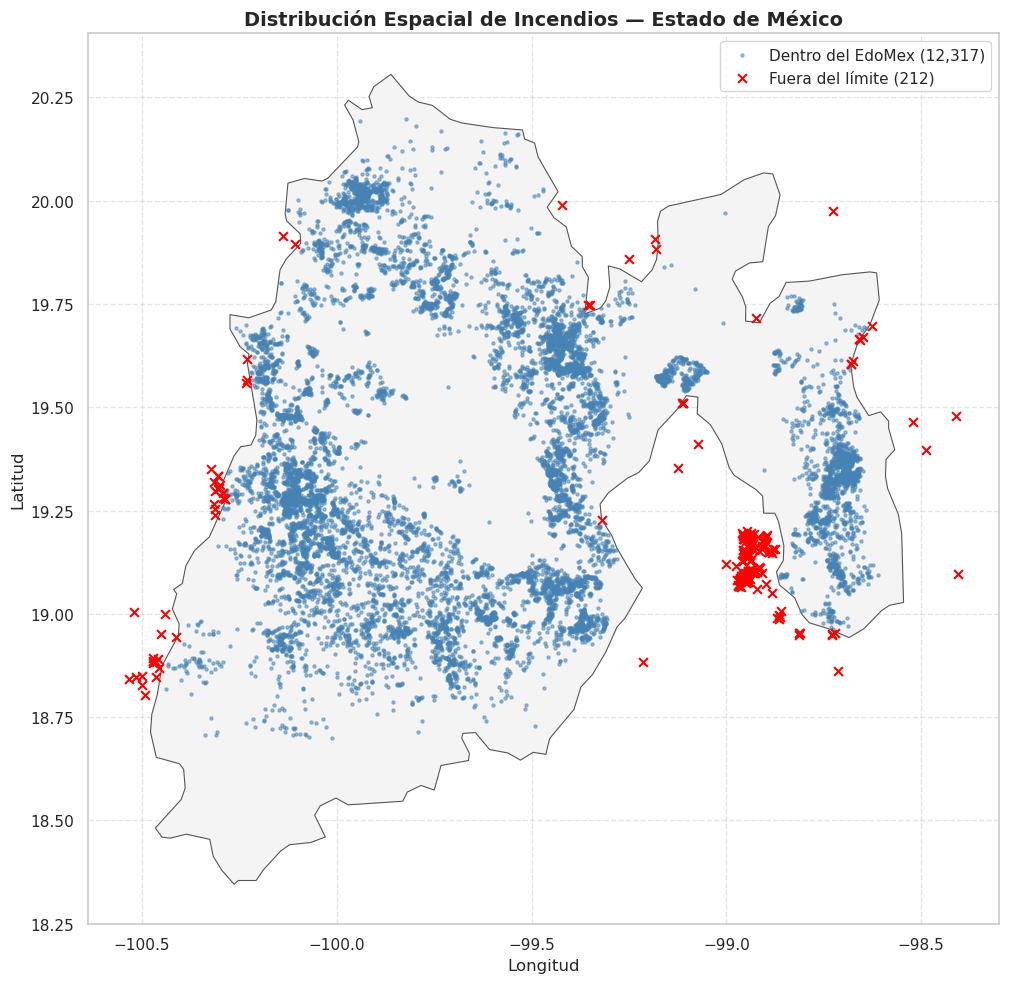

In [22]:
import sys, os, duckdb
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

# Configuración de base de datos
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from config.config import V2_DB

con = duckdb.connect(V2_DB)

# --- 1. CARGAR MAPA DEL EDOMEX ---
url = "https://raw.githubusercontent.com/angelnmara/geojson/master/mexicoHigh.json"
gdf_mexico = gpd.read_file(url)

# CORRECCIÓN: el GeoJSON ya trae CRS implícito, no forzar allow_override
gdf_edomex = gdf_mexico[gdf_mexico['name'] == 'México'].copy()
if gdf_edomex.crs is None:
    gdf_edomex = gdf_edomex.set_crs("EPSG:4326")

# --- 2. CARGAR INCENDIOS DESDE DUCKDB ---
df_inc = con.execute("""
    SELECT id_clave_inc, latitud, longitud
    FROM working.incendios
    WHERE latitud IS NOT NULL AND longitud IS NOT NULL
""").df()

total_sin_coords = con.execute("""
    SELECT COUNT(*) FROM working.incendios
    WHERE latitud IS NULL OR longitud IS NULL
""").fetchone()[0]

print(f"Incendios con coordenadas:    {len(df_inc):,}")
print(f"Incendios sin coordenadas:    {total_sin_coords:,}")

# Convertir a GeoDataFrame
gdf_inc = gpd.GeoDataFrame(
    df_inc,
    geometry=gpd.points_from_xy(df_inc['longitud'], df_inc['latitud']),
    crs="EPSG:4326"
)

# --- 3. CLASIFICACIÓN ESPACIAL ---
edomex_poly = gdf_edomex.union_all() if hasattr(gdf_edomex, 'union_all') else gdf_edomex.unary_union

gdf_inc['es_outlier']           = ~gdf_inc.geometry.within(edomex_poly)
# MEJORA: flag para el modelo (0 = dentro, 1 = en orilla/fuera)
gdf_inc['coord_fuera_poligono'] = gdf_inc['es_outlier'].astype(int)

dentro   = gdf_inc[~gdf_inc['es_outlier']]
outliers = gdf_inc[gdf_inc['es_outlier']]

print(f"\nDentro del polígono EdoMex:   {len(dentro):,}")
print(f"Fuera  del polígono EdoMex:   {len(outliers):,}  ← revisar visualmente")

if not outliers.empty:
    print("\nDetalle de outliers espaciales:")
    print(outliers[['id_clave_inc', 'latitud', 'longitud']].to_string(index=False))

# --- 4. GUARDAR FLAG EN LA BD ---
# Registramos qué incendios están fuera del polígono para usarlo en el pipeline
if not outliers.empty:
    ids_fuera = outliers['id_clave_inc'].tolist()
    placeholders = ', '.join([f"'{i}'" for i in ids_fuera])
    con.execute(f"""
        ALTER TABLE working.incendios
        ADD COLUMN IF NOT EXISTS coord_fuera_poligono INTEGER DEFAULT 0
    """)
    con.execute(f"""
        UPDATE working.incendios
        SET coord_fuera_poligono = 1
        WHERE id_clave_inc IN ({placeholders})
    """)
    con.execute("CHECKPOINT")
    print(f"\nFlag 'coord_fuera_poligono' guardado en working.incendios")

# --- 5. VISUALIZACIÓN ---
fig, ax = plt.subplots(figsize=(12, 10))

# Capa 1: polígono del EdoMex
gdf_edomex.plot(ax=ax, color='#f4f4f4', edgecolor='#555555',
                linewidth=0.8, label='Límite EdoMex')

# Capa 2: incendios válidos
dentro.plot(ax=ax, color='steelblue', markersize=5,
            alpha=0.5, label=f'Dentro del EdoMex ({len(dentro):,})')

# Capa 3: outliers espaciales
if not outliers.empty:
    outliers.plot(ax=ax, color='red', markersize=40,
                  marker='x', linewidths=1.5,
                  label=f'Fuera del límite ({len(outliers):,})')

ax.set_title('Distribución Espacial de Incendios — Estado de México',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

con.close()

### ENTIDAD OPERACIONES 

=== OUTLIERS: OPERACIONES ===

Estadísticas de duración (fecha_inicio → fecha_termino):


,0
total_registros,12703.0
con_duracion,12703.0
sin_duracion,0.0
dur_min,0.0
dur_max,25.0
dur_avg,0.1
dur_mediana,0.0
dur_q1,0.0
dur_q3,0.0



Q1: 0.0 días | Q3: 0.0 días | IQR: 0.0 días
Límite inferior: 0.0 días
Límite superior: 0.0 días

Outliers detectados por IQR: 552


,id_clave_inc,fecha_inicio,fecha_termino,duracion_dias,hora_deteccion,hora_llegada
0,24-15-0731,2024-04-15,2024-05-10,25,00:05:00,00:10:00
1,24-15-0439,2024-03-22,2024-04-16,25,00:10:00,00:30:00
2,24-15-0491,2024-03-21,2024-04-10,20,00:05:00,01:25:00
3,24-15-0324,2024-03-14,2024-04-03,20,00:20:00,01:20:00
4,24-15-0673,2024-03-21,2024-04-09,19,00:30:00,01:35:00
...,...,...,...,...,...,...
547,25-15-0415,2025-04-11,2025-04-12,1,00:05:00,01:45:00
548,25-15-0522,2025-04-17,2025-04-18,1,00:10:00,01:10:00
549,25-15-0535,2025-04-18,2025-04-19,1,00:05:00,01:30:00
550,25-15-0667,2025-05-01,2025-05-02,1,00:10:00,00:55:00



Distribución por rango de duración:


,rango,total
0,0 días,12151
1,1-3 días,462
2,4-7 días,58
3,8-15 días,27
4,16-30 días,5


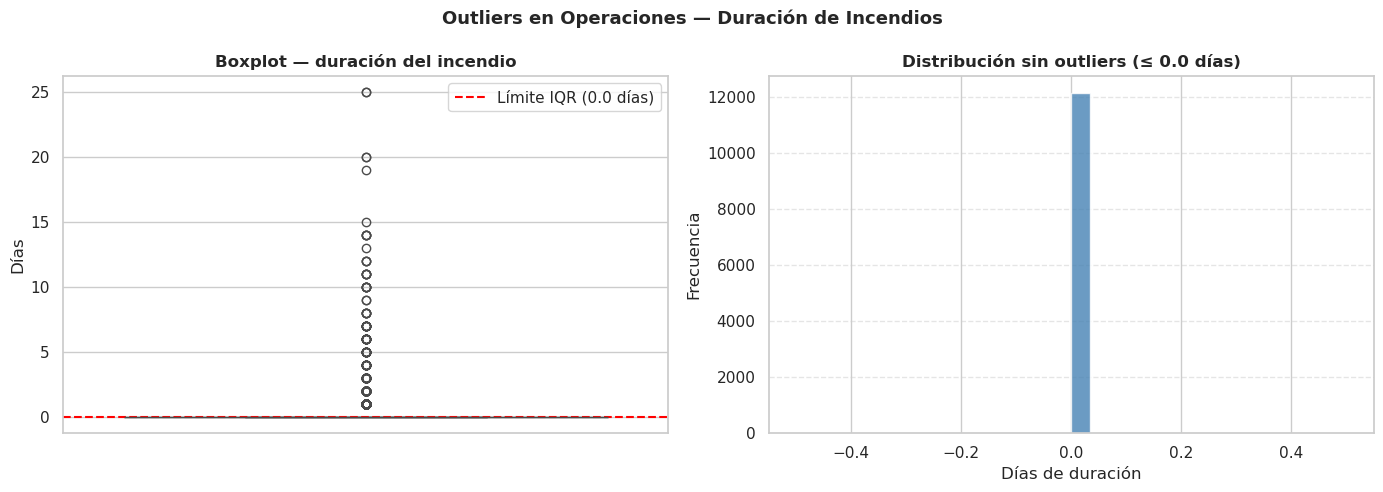

In [28]:
import sys, os, duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from config.config import V2_DB
 
con = duckdb.connect(V2_DB)
 
print("=== OUTLIERS: OPERACIONES ===\n")
 
# duracion_dias se calcula al vuelo desde fecha_inicio + fecha_termino
# No se guarda en la BD — eso ocurrirá en el pipeline de entrenamiento
 
# --- 1. ESTADÍSTICAS DESCRIPTIVAS ---
df_stats = con.execute("""
    SELECT
        COUNT(*)                                                                   AS total_registros,
        COUNT(o.fecha_termino)                                                     AS con_duracion,
        COUNT(*) - COUNT(o.fecha_termino)                                          AS sin_duracion,
 
        MIN(DATE_DIFF('day', i.fecha_inicio, o.fecha_termino))                    AS dur_min,
        MAX(DATE_DIFF('day', i.fecha_inicio, o.fecha_termino))                    AS dur_max,
        ROUND(AVG(DATE_DIFF('day', i.fecha_inicio, o.fecha_termino))::NUMERIC, 2) AS dur_avg,
        PERCENTILE_CONT(0.50) WITHIN GROUP (
            ORDER BY DATE_DIFF('day', i.fecha_inicio, o.fecha_termino))           AS dur_mediana,
        PERCENTILE_CONT(0.25) WITHIN GROUP (
            ORDER BY DATE_DIFF('day', i.fecha_inicio, o.fecha_termino))           AS dur_q1,
        PERCENTILE_CONT(0.75) WITHIN GROUP (
            ORDER BY DATE_DIFF('day', i.fecha_inicio, o.fecha_termino))           AS dur_q3
    FROM working.operaciones o
    JOIN working.incendios i ON o.id_clave_inc = i.id_clave_inc
    WHERE o.fecha_termino IS NOT NULL
""").df()
 
print("Estadísticas de duración (fecha_inicio → fecha_termino):")
display(df_stats.T)
 
# --- 2. DETECCIÓN DE OUTLIERS POR IQR ---
stats = con.execute("""
    SELECT
        PERCENTILE_CONT(0.25) WITHIN GROUP (
            ORDER BY DATE_DIFF('day', i.fecha_inicio, o.fecha_termino)) AS q1,
        PERCENTILE_CONT(0.75) WITHIN GROUP (
            ORDER BY DATE_DIFF('day', i.fecha_inicio, o.fecha_termino)) AS q3
    FROM working.operaciones o
    JOIN working.incendios i ON o.id_clave_inc = i.id_clave_inc
    WHERE o.fecha_termino IS NOT NULL
""").fetchone()
 
q1, q3 = stats
iqr      = q3 - q1
limite_superior = q3 + 1.5 * iqr
limite_inferior = q1 - 1.5 * iqr
 
print(f"\nQ1: {q1} días | Q3: {q3} días | IQR: {iqr} días")
print(f"Límite inferior: {limite_inferior:.1f} días")
print(f"Límite superior: {limite_superior:.1f} días")
 
# Registros fuera del rango IQR
df_outliers = con.execute(f"""
    SELECT
        o.id_clave_inc,
        i.fecha_inicio,
        o.fecha_termino,
        DATE_DIFF('day', i.fecha_inicio, o.fecha_termino) AS duracion_dias,
        o.hora_deteccion,
        o.hora_llegada
    FROM working.operaciones o
    JOIN working.incendios i ON o.id_clave_inc = i.id_clave_inc
    WHERE o.fecha_termino IS NOT NULL
      AND (
            DATE_DIFF('day', i.fecha_inicio, o.fecha_termino) > {limite_superior}
         OR DATE_DIFF('day', i.fecha_inicio, o.fecha_termino) < {limite_inferior}
      )
    ORDER BY DATE_DIFF('day', i.fecha_inicio, o.fecha_termino) DESC
""").df()
 
print(f"\nOutliers detectados por IQR: {len(df_outliers)}")
if not df_outliers.empty:
    display(df_outliers)
 
# --- 3. DISTRIBUCIÓN POR RANGO ---
df_rangos = con.execute("""
    SELECT
        CASE
            WHEN DATE_DIFF('day', i.fecha_inicio, o.fecha_termino) = 0
                THEN '0 días'
            WHEN DATE_DIFF('day', i.fecha_inicio, o.fecha_termino) BETWEEN 1 AND 3
                THEN '1-3 días'
            WHEN DATE_DIFF('day', i.fecha_inicio, o.fecha_termino) BETWEEN 4 AND 7
                THEN '4-7 días'
            WHEN DATE_DIFF('day', i.fecha_inicio, o.fecha_termino) BETWEEN 8 AND 15
                THEN '8-15 días'
            WHEN DATE_DIFF('day', i.fecha_inicio, o.fecha_termino) BETWEEN 16 AND 30
                THEN '16-30 días'
            WHEN DATE_DIFF('day', i.fecha_inicio, o.fecha_termino) > 30
                THEN 'Más de 30 días'
        END AS rango,
        COUNT(*) AS total
    FROM working.operaciones o
    JOIN working.incendios i ON o.id_clave_inc = i.id_clave_inc
    WHERE o.fecha_termino IS NOT NULL
    GROUP BY rango
    ORDER BY MIN(DATE_DIFF('day', i.fecha_inicio, o.fecha_termino))
""").df()
 
print("\nDistribución por rango de duración:")
display(df_rangos)
 
# --- 4. VISUALIZACIÓN ---
df_dur = con.execute("""
    SELECT DATE_DIFF('day', i.fecha_inicio, o.fecha_termino) AS duracion_dias
    FROM working.operaciones o
    JOIN working.incendios i ON o.id_clave_inc = i.id_clave_inc
    WHERE o.fecha_termino IS NOT NULL
""").df()
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Boxplot con línea de límite IQR
sns.boxplot(y=df_dur['duracion_dias'], ax=axes[0], color='steelblue')
axes[0].axhline(y=limite_superior, color='red', linestyle='--',
                label=f'Límite IQR ({limite_superior:.1f} días)')
axes[0].set_title('Boxplot — duración del incendio', fontweight='bold')
axes[0].set_ylabel('Días')
axes[0].legend()
 
# Histograma sin outliers para ver la distribución real
df_sin_outliers = df_dur[df_dur['duracion_dias'] <= limite_superior]
axes[1].hist(df_sin_outliers['duracion_dias'], bins=30,
             color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_title(f'Distribución sin outliers (≤ {limite_superior:.1f} días)',
                  fontweight='bold')
axes[1].set_xlabel('Días de duración')
axes[1].set_ylabel('Frecuencia')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
 
plt.suptitle('Outliers en Operaciones — Duración de Incendios',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()
 
con.close()

In [ ]:
import duckdb
import sys, os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from config.config import V2_DB

con = duckdb.connect(V2_DB)

df_largos = con.execute("""
    SELECT
        o.id_clave_inc,
        i.fecha_inicio,
        o.fecha_termino,
        DATE_DIFF('day', i.fecha_inicio, o.fecha_termino) AS duracion_dias,
        i.id_cvegeo,
        d.tamanio
    FROM working.operaciones o
    JOIN working.incendios i ON o.id_clave_inc = i.id_clave_inc
    JOIN working.danos d ON o.id_clave_inc = d.id_clave_inc
    WHERE DATE_DIFF('day', i.fecha_inicio, o.fecha_termino) > 15
    ORDER BY duracion_dias DESC
""").df()

display(df_largos)
con.close()

,id_clave_inc,fecha_inicio,fecha_termino,duracion_dias,id_cvegeo,tamanio
0,24-15-0731,2024-04-15,2024-05-10,25,15039,mayor a 100 hectareas
1,24-15-0439,2024-03-22,2024-04-16,25,15046,mayor a 100 hectareas
2,24-15-0324,2024-03-14,2024-04-03,20,15009,mayor a 100 hectareas
3,24-15-0491,2024-03-21,2024-04-10,20,15025,mayor a 100 hectareas
4,24-15-0673,2024-03-21,2024-04-09,19,15104,11 a 20 hectareas


### ENTIDAD DAÑOS

=== OUTLIERS: DAÑOS ===

1. Estadísticas descriptivas por tipo de cobertura:



,0
hojarasca_min,0.00000
hojarasca_max,19.91000
hojarasca_avg,0.00700
hojarasca_mediana,0.00000
hojarasca_q1,0.00000
hojarasca_q3,0.00000
arbustivo_min,0.00000
arbustivo_max,1489.00000
arbustivo_avg,6.18500
arbustivo_mediana,1.50000



2. Outliers por IQR en cada cobertura:



,Cobertura,Q1,Q3,IQR,Límite superior,Outliers (n)
0,hojarasca,0.0,0.000,0.000,0.0000,16
1,arbustivo,0.5,3.000,2.500,6.7500,1598
2,herbaceo,0.0,1.705,1.705,4.2625,1683
3,arbolado_adulto,0.0,0.000,0.000,0.0000,180
4,renuevo,0.0,0.000,0.000,0.0000,2327



3. Detalle de outliers cruzados con tamaño del incendio:

--- arbustivo (límite IQR: 6.75 ha) ---


,id_clave_inc,hectareas,tamanio,suma_total
0,23-15-0791,1489.000000,mayor a 100 hectareas,2679.260010
1,24-15-0916,1306.000000,mayor a 100 hectareas,1306.000000
2,25-15-0443,1140.479980,mayor a 100 hectareas,2319.139893
3,24-15-0872,882.309998,mayor a 100 hectareas,1482.310059
4,19-15-1049,850.000000,mayor a 100 hectareas,1530.000000
5,24-15-1112,800.000000,mayor a 100 hectareas,1592.689941
6,17-15-0922,800.000000,mayor a 100 hectareas,2565.000000
7,22-15-0915,619.334900,mayor a 100 hectareas,800.220032
8,24-15-0905,590.000000,mayor a 100 hectareas,952.729980
9,21-15-1314,567.000000,mayor a 100 hectareas,996.000000


--- herbaceo (límite IQR: 4.26 ha) ---


,id_clave_inc,hectareas,tamanio,suma_total
0,24-15-0324,1400.520020,mayor a 100 hectareas,1546.020020
1,25-15-0443,1140.479980,mayor a 100 hectareas,2319.139893
2,23-15-0791,1000.260010,mayor a 100 hectareas,2679.260010
3,21-15-0011,905.000000,mayor a 100 hectareas,935.000000
4,20-15-0375,902.000000,mayor a 100 hectareas,1269.000000
5,24-15-0799,866.330017,mayor a 100 hectareas,866.330017
6,24-15-0527,807.400024,mayor a 100 hectareas,807.400024
7,24-15-0541,754.979980,mayor a 100 hectareas,909.979980
8,19-15-1346,700.000000,mayor a 100 hectareas,1373.000000
9,21-15-0389,694.000000,mayor a 100 hectareas,700.000000



4. Distribución de coberturas:



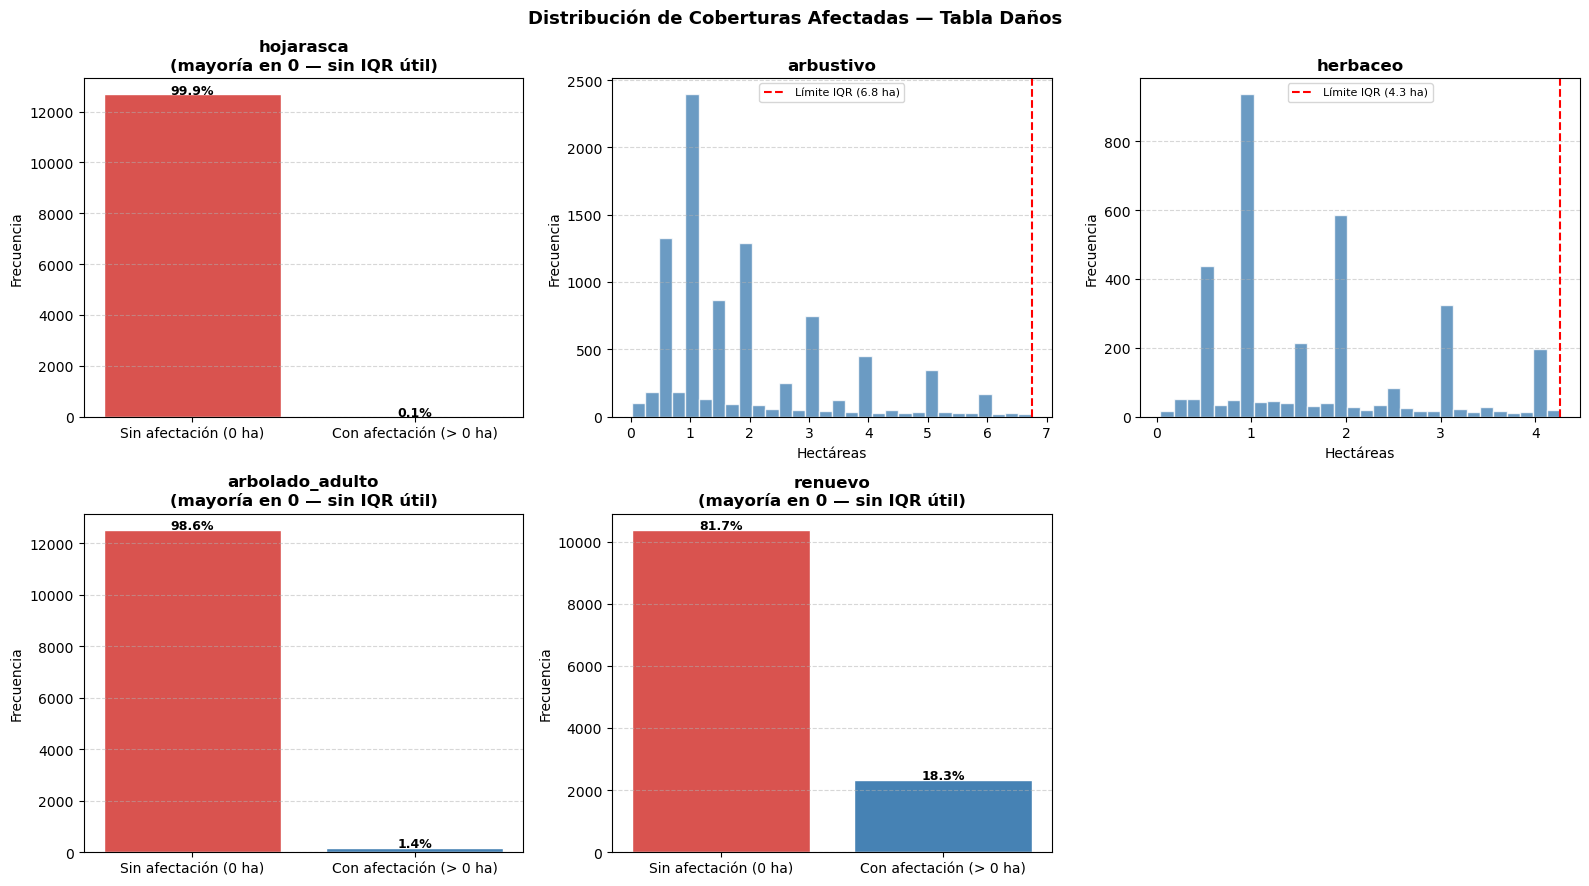

In [9]:
import sys, os, duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from config.config import V2_DB

con = duckdb.connect(V2_DB)

print("=== OUTLIERS: DAÑOS ===\n")

columnas_cobertura = ['hojarasca', 'arbustivo', 'herbaceo', 'arbolado_adulto', 'renuevo']

# --- 1. ESTADÍSTICAS DESCRIPTIVAS POR COBERTURA ---
print("1. Estadísticas descriptivas por tipo de cobertura:\n")

stats_query = ", ".join([f"""
    MIN({col})                                                      AS {col}_min,
    MAX({col})                                                      AS {col}_max,
    ROUND(AVG({col})::NUMERIC, 4)                                  AS {col}_avg,
    PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY {col})            AS {col}_mediana,
    PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY {col})            AS {col}_q1,
    PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY {col})            AS {col}_q3
""" for col in columnas_cobertura])

df_stats = con.execute(f"SELECT {stats_query} FROM working.danos").df()
display(df_stats.T)

# --- 2. DETECCIÓN DE OUTLIERS POR IQR EN CADA COBERTURA ---
print("\n2. Outliers por IQR en cada cobertura:\n")

resumen_outliers = []
limites = {}  # guardamos límites para usarlos en la visualización

for col in columnas_cobertura:
    stats = con.execute(f"""
        SELECT
            PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY {col}) AS q1,
            PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY {col}) AS q3
        FROM working.danos
        WHERE {col} IS NOT NULL
    """).fetchone()

    if stats and stats[0] is not None:
        q1, q3          = stats
        iqr             = q3 - q1
        limite_superior = q3 + 1.5 * iqr
        limite_inferior = max(0, q1 - 1.5 * iqr)
        limites[col]    = limite_superior

        n_outliers = con.execute(f"""
            SELECT COUNT(*) FROM working.danos
            WHERE {col} IS NOT NULL
              AND {col} > {limite_superior}
        """).fetchone()[0]

        resumen_outliers.append({
            'Cobertura':       col,
            'Q1':              round(q1, 4),
            'Q3':              round(q3, 4),
            'IQR':             round(iqr, 4),
            'Límite superior': round(limite_superior, 4),
            'Outliers (n)':    n_outliers
        })

df_resumen_outliers = pd.DataFrame(resumen_outliers)
display(df_resumen_outliers)

# --- 3. DETALLE DE OUTLIERS CRUZADO CON TAMAÑO ---
print("\n3. Detalle de outliers cruzados con tamaño del incendio:\n")

for col in columnas_cobertura:
    limite = limites.get(col, 0)
    if limite == 0:
        continue  # se analiza como proporción en la visualización

    df_det = con.execute(f"""
        SELECT
            id_clave_inc,
            {col}       AS hectareas,
            tamanio,
            COALESCE(hojarasca,0) + COALESCE(arbustivo,0) +
            COALESCE(herbaceo,0)  + COALESCE(arbolado_adulto,0) +
            COALESCE(renuevo,0)   AS suma_total
        FROM working.danos
        WHERE {col} IS NOT NULL
          AND {col} > {limite}
        ORDER BY {col} DESC
        LIMIT 10
    """).df()

    if not df_det.empty:
        print(f"--- {col} (límite IQR: {limite:.2f} ha) ---")
        display(df_det)

# --- 4. VISUALIZACIÓN ---
print("\n4. Distribución de coberturas:\n")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for idx, col in enumerate(columnas_cobertura):
    limite = limites.get(col, 0)
    ax     = axes[idx]

    # Columnas dominadas por 0: mostrar proporción 0 vs >0
    if limite == 0:
        df_prop = con.execute(f"""
            SELECT
                CASE WHEN {col} = 0 THEN 'Sin afectación (0 ha)'
                     ELSE 'Con afectación (> 0 ha)' END AS categoria,
                COUNT(*) AS total
            FROM working.danos
            WHERE {col} IS NOT NULL
            GROUP BY categoria
            ORDER BY categoria DESC
        """).df()

        colores_bar = ['#d9534f' if 'Sin' in c else 'steelblue'
                       for c in df_prop['categoria']]
        ax.bar(df_prop['categoria'], df_prop['total'],
               color=colores_bar, edgecolor='white')

        # Etiquetas con porcentaje
        total = df_prop['total'].sum()
        for i, (_, row) in enumerate(df_prop.iterrows()):
            pct = 100 * row['total'] / total
            ax.text(i, row['total'] + 20, f"{pct:.1f}%",
                    ha='center', fontsize=9, fontweight='bold')

        ax.set_title(f'{col}\n(mayoría en 0 — sin IQR útil)', fontweight='bold')
        ax.set_ylabel('Frecuencia')
        ax.grid(axis='y', linestyle='--', alpha=0.5)

    # Columnas con distribución real: histograma sin outliers
    else:
        df_col = con.execute(f"""
            SELECT {col} AS valor
            FROM working.danos
            WHERE {col} IS NOT NULL AND {col} > 0
              AND {col} <= {limite}
        """).df()

        ax.hist(df_col['valor'], bins=30,
                color='steelblue', edgecolor='white', alpha=0.8)
        ax.axvline(x=limite, color='red', linestyle='--',
                   label=f'Límite IQR ({limite:.1f} ha)')
        ax.set_title(f'{col}', fontweight='bold')
        ax.set_xlabel('Hectáreas')
        ax.set_ylabel('Frecuencia')
        ax.legend(fontsize=8)
        ax.grid(axis='y', linestyle='--', alpha=0.5)

# Ocultar subplot sobrante
axes[-1].set_visible(False)

plt.suptitle('Distribución de Coberturas Afectadas — Tabla Daños',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

con.close()

Negativos                    → ninguno  ✓
Inconsistencias suma/tamaño  → ninguna  ✓
Outliers problemáticos       → ninguno  ✓
Ceros sospechosos            → ninguno  ✓
Pendiente pipeline           → estandarizar "06 a 10" → "6 a 10"


* Variables más útiles:    arbustivo, herbaceo, renuevo
* Variables poco útiles:   hojarasca, arbolado_adulto

In [10]:
con = duckdb.connect(V2_DB)

# Estandarizar categoría duplicada en tamanio
resultado = con.execute("""
    UPDATE working.danos
    SET tamanio = '6 a 10 hectareas'
    WHERE tamanio = '06 a 10 hectareas'
""").fetchone()

con.execute("CHECKPOINT")

# Verificar que quedó bien
df_check = con.execute("""
    SELECT tamanio, COUNT(*) as total
    FROM working.danos
    GROUP BY tamanio
    ORDER BY total DESC
""").df()
display(df_check)

con.close()

,tamanio,total
0,0 a 5 hectareas,9646
1,6 a 10 hectareas,1259
2,11 a 20 hectareas,784
3,21 a 50 hectareas,551
4,mayor a 100 hectareas,256
5,51 a 100 hectareas,207


### ENTIDAD DEMOGRAFIA

=== OUTLIERS: DEMOGRAFÍA (población total por municipio/año) ===

1. Estadísticas de pob_total por año (hombres + mujeres):



,anio,municipios,pob_min,pob_max,pob_avg,pob_mediana,pob_q1,pob_q3
0,2015,125,4018.0,1713207.0,132759.0,42586.0,25157.0,106272.0
1,2016,125,4200.0,1705494.0,133899.0,43657.0,24937.0,106595.0
2,2017,125,4391.0,1696336.0,134961.0,44722.0,24695.0,106834.0
3,2018,125,4584.0,1687044.0,136046.0,45805.0,24457.0,108272.0
4,2019,125,4790.0,1677339.0,137132.0,46904.0,24207.0,109473.0
5,2020,125,4980.0,1661966.0,137894.0,47467.0,23883.0,109635.0
6,2021,125,5007.0,1657405.0,138328.0,47700.0,23778.0,109645.0
7,2022,125,5040.0,1656321.0,139037.0,48008.0,23714.0,109856.0
8,2023,125,5087.0,1658534.0,140010.0,48410.0,23661.0,110264.0
9,2024,125,5129.0,1660264.0,140928.0,48779.0,23483.0,110607.0



2. Municipios con población atípica (IQR sobre pob_total):

Q1: 23,649 | Q3: 109,667 | IQR: 86,018
Límite inferior: 0 hab
Límite superior: 238,694 hab

Municipios con población atípica: 215


,id_cvegeo,nombre_municipio,anio,pob_total
0,15033,ecatepec de morelos,2015,1713207.0
1,15033,ecatepec de morelos,2016,1705494.0
2,15033,ecatepec de morelos,2017,1696336.0
3,15033,ecatepec de morelos,2018,1687044.0
4,15033,ecatepec de morelos,2019,1677339.0
5,15033,ecatepec de morelos,2020,1661966.0
6,15033,ecatepec de morelos,2025,1661406.0
7,15033,ecatepec de morelos,2024,1660264.0
8,15033,ecatepec de morelos,2023,1658534.0
9,15033,ecatepec de morelos,2021,1657405.0



3. Top 5 municipios con mayor y menor población:

Mayor población:


,id_cvegeo,nombre_municipio,anio,pob_total
0,15033,ecatepec de morelos,2015,1713207.0
1,15033,ecatepec de morelos,2016,1705494.0
2,15033,ecatepec de morelos,2017,1696336.0
3,15033,ecatepec de morelos,2018,1687044.0
4,15033,ecatepec de morelos,2019,1677339.0


Menor población:


,id_cvegeo,nombre_municipio,anio,pob_total
0,15066,otzoloapan,2015,4018.0
1,15069,papalotla,2015,4099.0
2,15066,otzoloapan,2016,4200.0
3,15069,papalotla,2016,4267.0
4,15116,zacazonapan,2015,4280.0


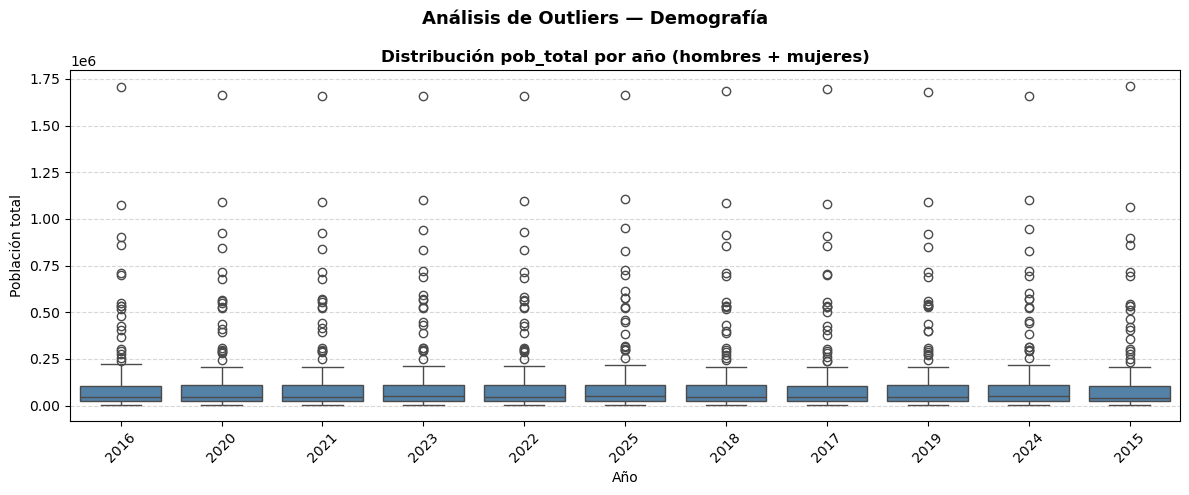

In [11]:
import sys, os, duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from config.config import V2_DB

con = duckdb.connect(V2_DB)

print("=== OUTLIERS: DEMOGRAFÍA (población total por municipio/año) ===\n")

# Suma hombres + mujeres — esta misma lógica se usará en el pipeline
DEMO_TOTAL = """
    SELECT
        id_cvegeo,
        anio,
        SUM(pob_total) AS pob_total
    FROM working.demografia
    GROUP BY id_cvegeo, anio
"""

# --- 1. ESTADÍSTICAS DESCRIPTIVAS POR AÑO ---
print("1. Estadísticas de pob_total por año (hombres + mujeres):\n")

df_stats = con.execute(f"""
    SELECT
        anio,
        COUNT(*)                                                      AS municipios,
        MIN(pob_total)                                                AS pob_min,
        MAX(pob_total)                                                AS pob_max,
        ROUND(AVG(pob_total)::NUMERIC, 0)                            AS pob_avg,
        PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY pob_total)      AS pob_mediana,
        PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY pob_total)      AS pob_q1,
        PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY pob_total)      AS pob_q3
    FROM ({DEMO_TOTAL})
    GROUP BY anio
    ORDER BY anio
""").df()
display(df_stats)

# --- 2. OUTLIERS POR IQR ---
print("\n2. Municipios con población atípica (IQR sobre pob_total):\n")

stats = con.execute(f"""
    SELECT
        PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY pob_total) AS q1,
        PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY pob_total) AS q3
    FROM ({DEMO_TOTAL})
""").fetchone()

q1, q3          = stats
iqr             = q3 - q1
limite_superior = q3 + 1.5 * iqr
limite_inferior = max(0, q1 - 1.5 * iqr)

print(f"Q1: {q1:,.0f} | Q3: {q3:,.0f} | IQR: {iqr:,.0f}")
print(f"Límite inferior: {limite_inferior:,.0f} hab")
print(f"Límite superior: {limite_superior:,.0f} hab")

df_outliers = con.execute(f"""
    SELECT
        dt.id_cvegeo,
        m.nombre_municipio,
        dt.anio,
        dt.pob_total
    FROM ({DEMO_TOTAL}) dt
    JOIN working.municipios m ON dt.id_cvegeo = m.id_cvegeo
    WHERE dt.pob_total > {limite_superior}
       OR dt.pob_total < {limite_inferior}
    ORDER BY dt.pob_total DESC
""").df()

print(f"\nMunicipios con población atípica: {len(df_outliers)}")
if not df_outliers.empty:
    display(df_outliers.head(20))

# --- 3. TOP 5 MAYOR Y MENOR POBLACIÓN ---
print("\n3. Top 5 municipios con mayor y menor población:\n")

df_top = con.execute(f"""
    SELECT dt.id_cvegeo, m.nombre_municipio, dt.anio, dt.pob_total
    FROM ({DEMO_TOTAL}) dt
    JOIN working.municipios m ON dt.id_cvegeo = m.id_cvegeo
    ORDER BY dt.pob_total DESC
    LIMIT 5
""").df()
print("Mayor población:")
display(df_top)

df_bottom = con.execute(f"""
    SELECT dt.id_cvegeo, m.nombre_municipio, dt.anio, dt.pob_total
    FROM ({DEMO_TOTAL}) dt
    JOIN working.municipios m ON dt.id_cvegeo = m.id_cvegeo
    WHERE dt.pob_total > 0
    ORDER BY dt.pob_total ASC
    LIMIT 5
""").df()
print("Menor población:")
display(df_bottom)

# --- 4. VISUALIZACIÓN ---
fig, ax = plt.subplots(figsize=(12, 5))

df_box = con.execute(f"""
    SELECT anio::VARCHAR AS anio, pob_total
    FROM ({DEMO_TOTAL})
""").df()

sns.boxplot(data=df_box, x='anio', y='pob_total',
            ax=ax, color='steelblue')
ax.set_title('Distribución pob_total por año (hombres + mujeres)',
             fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Población total')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Análisis de Outliers — Demografía', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

con.close()

Negativos en pob_total    → ninguno  ✓
Outliers problemáticos    → ninguno  ✓
Outliers estadísticos     → 425, todos municipios grandes reales  ✓
Cobertura 2015-2025       → completa  ✓
Join con incendios        → por año exacto  ✓

In [34]:
con.execute("""
    SELECT DISTINCT anio, COUNT(*) as municipios
    FROM working.demografia
    GROUP BY anio
    ORDER BY anio
""").df()

,anio,municipios
0,2015,250
1,2016,250
2,2017,250
3,2018,250
4,2019,250
5,2020,250
6,2021,250
7,2022,250
8,2023,250
9,2024,250


### ENTIDAD CLIMA

In [40]:
con = duckdb.connect(V2_DB)

# Ver si hay algún patrón en los nombres de las variables
df_dic = con.execute("""
    SELECT 
        id_variable,
        nombre_completo,
        unidad_de_medida,
        fuente
    FROM working.diccionario
    ORDER BY fuente, id_variable
    LIMIT 20
""").df()
display(df_dic)

,id_variable,nombre_completo,unidad_de_medida,fuente
0,NDMI,normalized difference moisture index,Adimensional (-1 a 1),google earth engine
1,NDVI,normalized difference vegetation index,Adimensional (-1 a 1),google earth engine
2,NDWI,normalized difference water index,Adimensional (-1 a 1),google earth engine
3,AIRMASS,air mass,dimensionless,nasa
4,ALLSKY_KT,all sky insolation clearness index,dimensionless,nasa
5,ALLSKY_NKT,all sky normalized insolation clearness index,dimensionless,nasa
6,ALLSKY_SFC_LW_DWN,all sky surface longwave downward irradiance,MJ/m^2/day,nasa
7,ALLSKY_SFC_LW_UP,all sky surface longwave upward irradiance,MJ/m^2/day,nasa
8,ALLSKY_SFC_PAR_DIFF,all sky surface diffuse par,MJ/m^2/day,nasa
9,ALLSKY_SFC_PAR_DIRH,all sky surface direct horizontal par,MJ/m^2/day,nasa


In [ ]:
con = duckdb.connect(V2_DB)

df_rangos = con.execute("""
    SELECT 
        unidad_de_medida,
        COUNT(*) AS total_variables,
        STRING_AGG(id_variable, ', ' ORDER BY id_variable) AS variables
    FROM working.diccionario
    GROUP BY unidad_de_medida
    ORDER BY total_variables DESC
""").df()
display(df_rangos)

,unidad_de_medida,total_variables,variables
0,MJ/m^2/day,35,"ALLSKY_SFC_LW_DWN, ALLSKY_SFC_LW_UP, ALLSKY_SF..."
1,C,29,"CLOUD_BT, CLOUD_BT_MAX, CLOUD_BT_MIN, CLOUD_TT..."
2,m/s,18,"U10M, U2M, U50M, V10M, V2M, V50M, WS10M, WS10M..."
3,dimensionless,12,"AIRMASS, ALLSKY_KT, ALLSKY_NKT, ALLSKY_SRF_ALB..."
4,%,7,"CLOUD_AMT, CLOUD_AMT_DAY, CLOUD_AMT_NIGHT, IME..."
5,1,5,"FRSEAICE, FRSNO, GWETPROF, GWETROOT, GWETTOP"
6,mm/day,5,"EVLAND, IMERG_PRECTOT, PRECSNO, PRECSNOLAND, P..."
7,m,4,"DISPH, GWM_HEIGHT, GWM_HEIGHT_ANOMALY, Z0M"
8,kPa,4,"PBLTOP, PS, SLP, TROPPB"
9,Degrees,4,"SZA, WD10M, WD2M, WD50M"


=== OUTLIERS: CLIMATOLOGÍA ===
Procesando ~18M de registros...

CAPA 1: Violaciones de rangos físicos por variable

Variables con violaciones físicas: 7


,id_variable,unidad,rango_valido,violaciones
3,TROPPB,kPa,"[50, 110]",127030
0,V50M,m/s,"[0, 50]",37260
2,V2M,m/s,"[0, 50]",34712
4,U50M,m/s,"[0, 50]",33539
5,V10M,m/s,"[0, 50]",33456
1,U10M,m/s,"[0, 50]",31815
6,U2M,m/s,"[0, 50]",31048



CAPA 2: Estadísticas y outliers IQR por variable

Estadísticas completas por variable:


,id_variable,total,con_valor,nulos,pct_cobertura,minimo,maximo,promedio,mediana,q1,q3,iqr,limite_superior,limite_inferior,outliers_pct
0,AIRMASS,127030,127030,0,100.0,2.190000,5.950000,3.450,3.370000,2.910000,3.950000,1.040000,5.510000,1.350000,100
1,ALLSKY_KT,127030,127030,0,100.0,0.090000,0.810000,0.674,0.690000,0.630000,0.740000,0.110000,0.905000,0.465000,100
2,ALLSKY_NKT,127030,118788,8242,93.5,0.110000,1.000000,0.829,0.850000,0.760000,0.920000,0.160000,1.160000,0.520000,100
3,ALLSKY_SFC_LW_DWN,127030,127030,0,100.0,19.430000,39.330002,26.712,26.540001,24.540001,28.490000,3.949999,34.414997,18.615002,100
4,ALLSKY_SFC_LW_UP,127030,127030,0,100.0,29.809999,46.580002,36.697,36.509998,35.169998,38.099998,2.930000,42.494999,30.774998,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,WS50M,127030,127030,0,100.0,0.850000,15.430000,3.407,3.240000,2.660000,3.920000,1.260000,5.810000,0.770000,100
141,WS50M_MAX,127030,127030,0,100.0,1.580000,19.770000,5.623,5.520000,4.570000,6.480000,1.910000,9.344999,1.705000,100
142,WS50M_MIN,127030,127030,0,100.0,0.000000,12.890000,1.207,0.870000,0.480000,1.560000,1.080000,3.180000,-1.140000,100
143,WS50M_RANGE,127030,127030,0,100.0,0.410000,11.660000,4.417,4.360000,3.430000,5.300000,1.870000,8.105000,0.625000,100



Variables con MAX > límite IQR (posibles outliers severos): 93


,id_variable,q3,limite_superior,maximo,ratio_max_q3
76,PRECTOTCORR,0.290000,0.725000,46.049999,158.8
48,EVPTRNS,0.150000,0.330000,3.690000,24.6
138,WS2M_MIN,0.520000,1.060000,6.970000,13.4
28,CLOUD_OD,4.070000,6.815001,36.930000,9.1
134,WS10M_MIN,1.020000,2.070000,9.230000,9.0
127,V2M,0.860000,2.255000,7.470000,8.7
142,WS50M_MIN,1.560000,3.180000,12.890000,8.3
58,HDD18_3,1.870000,4.675000,15.120000,8.1
128,V50M,1.830000,4.890000,13.990000,7.6
126,V10M,1.410000,3.630000,10.670000,7.6



Variables con menos del 70% de cobertura: 23


,id_variable,pct_cobertura,con_valor,total
25,CLOUD_BT,0.0,0,127030
26,CLOUD_BT_MAX,0.0,0,127030
27,CLOUD_BT_MIN,0.0,0,127030
29,CLOUD_TT,0.0,0,127040
30,CLOUD_TT_MAX,0.0,0,127040
31,CLOUD_TT_MIN,0.0,0,127040
55,GWM_HEIGHT,0.0,0,127030
56,GWM_HEIGHT_ANOMALY,0.0,0,127030
59,IMERG_PRECLIQUID_PROB,0.0,0,127030
60,IMERG_PRECTOT,0.0,0,127030


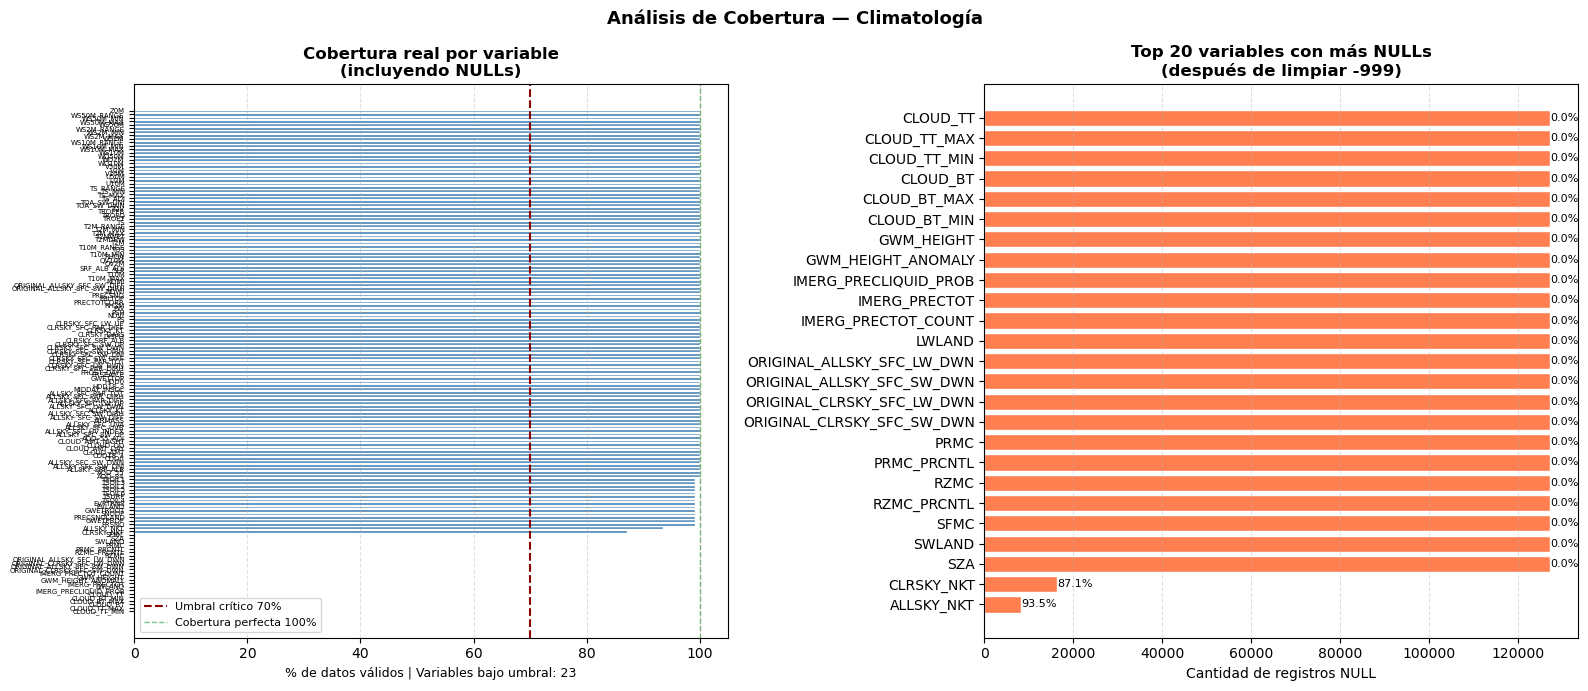

In [4]:
import sys, os, duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from config.config import V2_DB

con = duckdb.connect(V2_DB)

print("=== OUTLIERS: CLIMATOLOGÍA ===")
print("Procesando ~18M de registros...\n")

# -------------------------------------------------------------------
# CAPA 1: RANGOS FÍSICOS IMPOSIBLES POR UNIDAD DE MEDIDA
# Valores fuera de estos rangos son físicamente imposibles
# independientemente del modelo
# -------------------------------------------------------------------
RANGOS_FISICOS = {
    '∘C':                  (-10,  45),    # Temperatura EdoMex
    'm/s':                 (  0,  50),    # Velocidad del viento
    '%':                   (  0, 100),    # Porcentajes
    'MJ/m2/day':           (  0, None),   # Radiación, siempre >= 0
    'mm/day':              (  0, None),   # Precipitación, siempre >= 0
    'Adimensional (-1 a 1)': (-1,   1),   # NDMI, NDVI, NDWI
    '1 (Fracción)':        (  0,   1),    # Fracciones
    'm3/m−3':              (  0,   1),    # Humedad de suelo
    'kPa':                 ( 50, 110),    # Presión atmosférica
    'cm':                  (  0, None),   # Siempre >= 0
    'g/kg':                (  0, None),   # Humedad específica
    'kg/m−3':              (  0, None),   # Densidad
    'kg/m−2':              (  0, None),   # Agua precipitable
    'Days':                (  0,  31),    # Días del mes
    'degree−day−c':        (None, None),  # Sin rango definido → IQR
    'Degrees':             (  0, 360),    # Dirección del viento
    'Dobsons':             (100, 500),    # Ozono total
    'W/m−2×40':            (  0, None),   # Índice UV
    'm':                   (  0, None),   # Alturas, siempre >= 0
    'Dimensionless':       (None, None),  # Sin rango definido → IQR
    'Por definir':         (None, None),  # Sin rango definido → IQR
    'count':               (  0, None),   # Conteos, siempre >= 0
}

# Obtener variables con su unidad
df_dic = con.execute("""
    SELECT id_variable, unidad_de_medida
    FROM working.diccionario
""").df()

# -------------------------------------------------------------------
# CAPA 1: Detectar violaciones de rangos físicos
# -------------------------------------------------------------------
print("CAPA 1: Violaciones de rangos físicos por variable\n")

resultados_fisicos = []

for _, row in df_dic.iterrows():
    var       = row['id_variable']
    unidad    = row['unidad_de_medida']
    rango     = RANGOS_FISICOS.get(unidad)

    if rango is None:
        continue

    min_val, max_val = rango

    # Construir condición
    condiciones = []
    if min_val is not None:
        condiciones.append(f"resultado_numerico < {min_val}")
    if max_val is not None:
        condiciones.append(f"resultado_numerico > {max_val}")

    if not condiciones:
        continue

    where_clause = " OR ".join(condiciones)

    n_violaciones = con.execute(f"""
        SELECT COUNT(*) FROM working.climatologia
        WHERE id_variable = '{var}'
          AND resultado_numerico IS NOT NULL
          AND ({where_clause})
    """).fetchone()[0]

    if n_violaciones > 0:
        resultados_fisicos.append({
            'id_variable':   var,
            'unidad':        unidad,
            'rango_valido':  f"[{min_val}, {max_val}]",
            'violaciones':   n_violaciones
        })

df_fisicos = pd.DataFrame(resultados_fisicos)

if not df_fisicos.empty:
    print(f"Variables con violaciones físicas: {len(df_fisicos)}")
    display(df_fisicos.sort_values('violaciones', ascending=False))
else:
    print("✓ Ninguna variable tiene valores fuera de su rango físico.\n")

# -------------------------------------------------------------------
# CAPA 2: IQR sobre todas las variables
# Un solo query masivo para eficiencia con 18M de registros
# -------------------------------------------------------------------
print("\nCAPA 2: Estadísticas y outliers IQR por variable\n")

df_stats = con.execute("""
    SELECT
        id_variable,
        COUNT(*)                                                          AS total,
        COUNT(resultado_numerico)                                         AS con_valor,
        COUNT(*) - COUNT(resultado_numerico)                              AS nulos,
        ROUND(100.0 * COUNT(resultado_numerico) / COUNT(*), 1)           AS pct_cobertura,
        MIN(resultado_numerico)                                           AS minimo,
        MAX(resultado_numerico)                                           AS maximo,
        ROUND(AVG(resultado_numerico)::NUMERIC, 4)                        AS promedio,
        PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY resultado_numerico)  AS mediana,
        PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY resultado_numerico)  AS q1,
        PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY resultado_numerico)  AS q3
    FROM working.climatologia
    GROUP BY id_variable          -- SIN el WHERE, para contar NULLs reales
    ORDER BY id_variable
""").df()

# Calcular límites IQR y contar outliers
df_stats['iqr']             = df_stats['q3'] - df_stats['q1']
df_stats['limite_superior'] = df_stats['q3'] + 1.5 * df_stats['iqr']
df_stats['limite_inferior'] = df_stats['q1'] - 1.5 * df_stats['iqr']
df_stats['outliers_pct']    = round(
    100 * (
        (df_stats['maximo'] > df_stats['limite_superior']) |
        (df_stats['minimo'] < df_stats['limite_inferior'])
    ).astype(int), 1
)

print("Estadísticas completas por variable:")
display(df_stats)

# -------------------------------------------------------------------
# Variables con MAX muy alejado del Q3 → outliers severos
# -------------------------------------------------------------------
df_stats['ratio_max_q3'] = df_stats.apply(
    lambda r: round(r['maximo'] / r['q3'], 1) if r['q3'] > 0 else None, axis=1
)

df_severos = df_stats[
    df_stats['maximo'] > df_stats['limite_superior']
].sort_values('ratio_max_q3', ascending=False)

print(f"\nVariables con MAX > límite IQR (posibles outliers severos): {len(df_severos)}")
if not df_severos.empty:
    display(df_severos[['id_variable', 'q3', 'limite_superior',
                         'maximo', 'ratio_max_q3']].head(20))

# -------------------------------------------------------------------
# Variables con cobertura baja → candidatas a descartar en pipeline
# -------------------------------------------------------------------
df_baja_cobertura = df_stats[df_stats['pct_cobertura'] < 70].sort_values('pct_cobertura')

print(f"\nVariables con menos del 70% de cobertura: {len(df_baja_cobertura)}")
if not df_baja_cobertura.empty:
    display(df_baja_cobertura[['id_variable', 'pct_cobertura', 'con_valor', 'total']])

# -------------------------------------------------------------------
# VISUALIZACIÓN
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Gráfica izquierda: cobertura real por variable ---
df_sorted = df_stats.sort_values('pct_cobertura', ascending=True)
colores   = ['red' if x < 70 else 'steelblue' for x in df_sorted['pct_cobertura']]

axes[0].barh(range(len(df_sorted)), df_sorted['pct_cobertura'],
             color=colores, edgecolor='white', height=0.8)
axes[0].axvline(x=70, color='darkred', linestyle='--',
                linewidth=1.5, label='Umbral crítico 70%')
axes[0].axvline(x=100, color='green', linestyle='--',
                linewidth=1, alpha=0.5, label='Cobertura perfecta 100%')
axes[0].set_title('Cobertura real por variable\n(incluyendo NULLs)', fontweight='bold')
axes[0].set_xlabel('% de datos válidos (no nulos)')
axes[0].set_yticks(range(len(df_sorted)))
axes[0].set_yticklabels(df_sorted['id_variable'], fontsize=5)
axes[0].set_xlim(0, 105)
axes[0].legend(fontsize=8)
axes[0].grid(axis='x', linestyle='--', alpha=0.4)

n_bajo = (df_sorted['pct_cobertura'] < 70).sum()
axes[0].set_xlabel(
    f'% de datos válidos | Variables bajo umbral: {n_bajo}', fontsize=9
)

df_top_nulos = df_stats.nlargest(25, 'nulos')[['id_variable', 'nulos', 'pct_cobertura']]

barras = axes[1].barh(df_top_nulos['id_variable'], df_top_nulos['nulos'],
                      color='coral', edgecolor='white')
axes[1].set_title('Top 20 variables con más NULLs\n(después de limpiar -999)',
                  fontweight='bold')
axes[1].set_xlabel('Cantidad de registros NULL')
axes[1].invert_yaxis()
axes[1].grid(axis='x', linestyle='--', alpha=0.4)

# Etiqueta con % de cobertura al final de cada barra
for barra, (_, row) in zip(barras, df_top_nulos.iterrows()):
    axes[1].text(barra.get_width() + 100, barra.get_y() + barra.get_height()/2,
                 f"{row['pct_cobertura']}%",
                 va='center', fontsize=8, color='black')

plt.suptitle('Análisis de Cobertura — Climatología', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
df_bajo_umbral = df_stats[df_stats['pct_cobertura'] < 70]\
    .sort_values('pct_cobertura')[['id_variable', 'pct_cobertura', 'nulos', 'total']]
display(df_bajo_umbral)

,id_variable,pct_cobertura,nulos,total
25,CLOUD_BT,0.0,127030,127030
26,CLOUD_BT_MAX,0.0,127030,127030
27,CLOUD_BT_MIN,0.0,127030,127030
29,CLOUD_TT,0.0,127040,127040
30,CLOUD_TT_MAX,0.0,127040,127040
31,CLOUD_TT_MIN,0.0,127040,127040
55,GWM_HEIGHT,0.0,127030,127030
56,GWM_HEIGHT_ANOMALY,0.0,127030,127030
59,IMERG_PRECLIQUID_PROB,0.0,127030,127030
60,IMERG_PRECTOT,0.0,127030,127030


Se eliminaran todas las variables que tiene NULL se quedan aquellas que tienen arriaba de un umbral del 70%

## 4. DECISIONES INFORMADAS 

### ENTIDAD CLIMA

In [2]:
import sys, os, duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from config.config import V2_DB

con = duckdb.connect(V2_DB)

df_decision = con.execute("""
    SELECT
        id_variable,
        COUNT(*)                                                         AS total,
        COUNT(resultado_numerico)                                        AS con_valor,
        COUNT(*) - COUNT(resultado_numerico)                             AS nulos,
        ROUND(100.0 * COUNT(resultado_numerico) / COUNT(*), 2)          AS pct_cobertura
    FROM working.climatologia
    GROUP BY id_variable
    HAVING ROUND(100.0 * COUNT(resultado_numerico) / COUNT(*), 2) >= 70
       AND ROUND(100.0 * COUNT(resultado_numerico) / COUNT(*), 2) < 100
    ORDER BY pct_cobertura ASC
""").df()

print(f"Variables entre 70% y 100% de cobertura: {len(df_decision)}")
display(df_decision)

con.close()

Variables entre 70% y 100% de cobertura: 16


,id_variable,total,con_valor,nulos,pct_cobertura
0,CLRSKY_NKT,127040,110703,16337,87.14
1,ALLSKY_NKT,127030,118788,8242,93.51
2,GWETROOT,127030,125980,1050,99.17
3,TSOIL3,127030,125980,1050,99.17
4,TSURF,127030,125980,1050,99.17
5,SNODP,127030,125980,1050,99.17
6,TSOIL1,127030,125980,1050,99.17
7,TSOIL4,127030,125980,1050,99.17
8,GWETPROF,127030,125980,1050,99.17
9,EVLAND,127032,125982,1050,99.17



En caso de se lleguen a quedar hacemos esta interpolacion por lo mientras solo quedan propuestas de llenado, y los analisis solamente ignoraran los NULL no los afecta

Las variables de temperatura del suelo (TSOIL1 a TSOIL6), humedad (GWETROOT, GWETPROF), nieve (FRSNO, SNODP) y evapotranspiración (EVLAND, EVPTRNS) son series temporales continuas

Interpolación temporal hacia adelante/atrás
→ Si día -3 tiene NULL, usar promedio de día -4 y día -2
→ Respeta la tendencia climática del período

Para CLRSKY_NKT y ALLSKY_NKT que son índices de claridad del cielo, la mejor técnica es

Mediana por mes y municipio
→ El índice de claridad es estacional
→ Imputar con la mediana del mismo mes en otros años